# Premier League Probability Engine

## Phase 2: Feature Engineering

The Elo model developed in Notebook 1 provides a baseline measure of team strength.

This notebook focuses on constructing the features that will be available before each match. These features will later be used to predict match outcomes and compare the model's probabilities with bookmaker odds.

The key principle throughout this notebook is to avoid look-ahead bias. Every feature must be calculated using only information that would have been known before kickoff.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

## 1. Loading multiple Premier League seasons

The first Elo model used only the 2024–25 season.

For predictive modelling, several seasons are needed so that team ratings and rolling features have enough historical information. This also means teams do not all begin the target season with identical ratings.

The code below loads Premier League match data from 2015–16 through 2024–25 and combines the seasons into one chronological dataset.

In [2]:
season_codes = {
    "2015-16": "1516",
    "2016-17": "1617",
    "2017-18": "1718",
    "2018-19": "1819",
    "2019-20": "1920",
    "2020-21": "2021",
    "2021-22": "2122",
    "2022-23": "2223",
    "2023-24": "2324",
    "2024-25": "2425",
}

season_frames = []

for season_name, season_code in season_codes.items():
    url = (
        "https://www.football-data.co.uk/mmz4281/"
        f"{season_code}/E0.csv"
    )

    season_data = pd.read_csv(url)

    season_data["Season"] = season_name

    season_frames.append(season_data)

matches_all = pd.concat(
    season_frames,
    ignore_index=True,
)

print(f"Seasons loaded: {len(season_frames)}")
print(f"Total matches: {len(matches_all)}")

matches_all[["Season", "Date", "HomeTeam", "AwayTeam"]].head()

Seasons loaded: 10
Total matches: 3800


C:\Users\kiera\AppData\Local\Temp\ipykernel_3324\2526682352.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  season_data["Season"] = season_name


,Season,Date,HomeTeam,AwayTeam
0,2015-16,08/08/2015,Bournemouth,Aston Villa
1,2015-16,08/08/2015,Chelsea,Swansea
2,2015-16,08/08/2015,Everton,Watford
3,2015-16,08/08/2015,Leicester,Sunderland
4,2015-16,08/08/2015,Man United,Tottenham


## 2. Checking column consistency

Before combining data from different seasons, it is important to confirm that the files use compatible column names.

Football-data files sometimes gain or lose bookmaker columns between seasons. The core match columns should remain consistent, but this must be checked rather than assumed.

In [3]:
column_counts = {}

for season_name, season_code in season_codes.items():
    url = (
        "https://www.football-data.co.uk/mmz4281/"
        f"{season_code}/E0.csv"
    )

    season_data = pd.read_csv(url)

    column_counts[season_name] = len(season_data.columns)

pd.Series(column_counts, name="Number of columns")

2015-16     65
2016-17     65
2017-18     65
2018-19     62
2019-20    106
2020-21    106
2021-22    106
2022-23    106
2023-24    106
2024-25    120
Name: Number of columns, dtype: int64

In [4]:
required_columns = [
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
]

missing_columns = {}

for season_name, season_code in season_codes.items():
    url = (
        "https://www.football-data.co.uk/mmz4281/"
        f"{season_code}/E0.csv"
    )

    season_data = pd.read_csv(url)

    missing = [
        column
        for column in required_columns
        if column not in season_data.columns
    ]

    missing_columns[season_name] = missing

missing_columns

{'2015-16': [],
 '2016-17': [],
 '2017-18': [],
 '2018-19': [],
 '2019-20': [],
 '2020-21': [],
 '2021-22': [],
 '2022-23': [],
 '2023-24': [],
 '2024-25': []}

## 3. Selecting the core match columns

The raw files contain many bookmaker and match-statistics columns that vary between seasons.

For the first feature-engineering stage, only the columns needed to identify each match and its final result are retained. Additional variables can be added later when they have a clear modelling purpose.

In [5]:
core_columns = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
]

matches = matches_all[core_columns].copy()

matches.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,2015-16,08/08/2015,Bournemouth,Aston Villa,0,1,A
1,2015-16,08/08/2015,Chelsea,Swansea,2,2,D
2,2015-16,08/08/2015,Everton,Watford,2,2,D
3,2015-16,08/08/2015,Leicester,Sunderland,4,2,H
4,2015-16,08/08/2015,Man United,Tottenham,1,0,H


In [6]:
print(f"Rows: {matches.shape[0]}")
print(f"Columns: {matches.shape[1]}")

Rows: 3800
Columns: 7


In [7]:
matches.isna().sum()

Season      0
Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
dtype: int64

## 4. Converting dates and ordering matches

All predictive features must be calculated using information available before each match.

The matches are therefore converted into proper datetime values and sorted chronologically. This ensures that rolling statistics and Elo ratings are updated in the correct order and prevents look-ahead bias.

In [8]:
# Convert match dates safely when different seasons use different formats
matches["Date"] = pd.to_datetime(
    matches["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce",
)

# Stop immediately if any dates failed to parse
missing_dates = matches["Date"].isna().sum()

assert missing_dates == 0, (
    f"{missing_dates} match dates could not be parsed."
)

# Sort every fixture chronologically to prevent look-ahead bias
matches = (
    matches
    .sort_values(
        ["Date", "HomeTeam", "AwayTeam"]
    )
    .reset_index(drop=True)
)

# Validate that each season contains 380 correctly dated matches
season_date_validation = (
    matches
    .groupby("Season")["Date"]
    .agg(
        FirstDate="min",
        LastDate="max",
        MatchCount="count",
    )
)

assert season_date_validation["MatchCount"].eq(380).all()

print("All match dates parsed successfully.")
print(f"Missing dates: {missing_dates}")

season_date_validation

All match dates parsed successfully.
Missing dates: 0


,FirstDate,LastDate,MatchCount
Season,,,
2015-16,2015-08-08,2016-05-17,380
2016-17,2016-08-13,2017-05-21,380
2017-18,2017-08-11,2018-05-13,380
2018-19,2018-08-10,2019-05-12,380
2019-20,2019-08-09,2020-07-26,380
2020-21,2020-09-12,2021-05-23,380
2021-22,2021-08-13,2022-05-22,380
2022-23,2022-08-05,2023-05-28,380
2023-24,2023-08-11,2024-05-19,380


In [9]:
matches = (
    matches
    .sort_values(["Date", "HomeTeam", "AwayTeam"])
    .reset_index(drop=True)
)

matches[["Season", "Date", "HomeTeam", "AwayTeam"]].head(10)

,Season,Date,HomeTeam,AwayTeam
0,2015-16,2015-08-08,Bournemouth,Aston Villa
1,2015-16,2015-08-08,Chelsea,Swansea
2,2015-16,2015-08-08,Everton,Watford
3,2015-16,2015-08-08,Leicester,Sunderland
4,2015-16,2015-08-08,Man United,Tottenham
5,2015-16,2015-08-08,Norwich,Crystal Palace
6,2015-16,2015-08-09,Arsenal,West Ham
7,2015-16,2015-08-09,Newcastle,Southampton
8,2015-16,2015-08-09,Stoke,Liverpool
9,2015-16,2015-08-10,West Brom,Man City


In [10]:
print("First match date:", matches["Date"].min())
print("Last match date:", matches["Date"].max())

First match date: 2015-08-08 00:00:00
Last match date: 2025-05-25 00:00:00


## 5. Creating pre-match Elo features

The first engineered features will represent each team's estimated strength immediately before kickoff.

To avoid target leakage, the rating used as a feature must be recorded before the result of the current match is used to update the Elo system. Each match will therefore follow this sequence:

1. Retrieve the current home and away ratings.
2. Store those ratings as pre-match features.
3. Calculate the expected match scores.
4. Observe the match result.
5. Update both teams' ratings.

The Elo parameters are kept consistent with the baseline model developed in Notebook 1:

- Initial team rating: $1500$
- Update factor: $K=20$
- Home-advantage adjustment: $H=50$

For the initial implementation, ratings will carry continuously across season boundaries. This preserves information about team strength between adjacent seasons. Seasonal rating regression can later be investigated as a modelling extension.

In [11]:
# Elo model parameters
initial_rating = 1500
k_factor = 20
home_advantage = 50


def expected_score(rating_a, rating_b):
    """
    Calculate Team A's expected score against Team B.

    Parameters
    ----------
    rating_a : float
        Elo rating of Team A, including any applicable adjustment.
    rating_b : float
        Elo rating of Team B.

    Returns
    -------
    float
        Expected score between 0 and 1.
    """
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def actual_scores_from_goals(home_goals, away_goals):
    """
    Convert the match score into Elo actual scores.

    Returns
    -------
    tuple
        Home and away actual scores.
    """
    if home_goals > away_goals:
        return 1.0, 0.0

    if home_goals < away_goals:
        return 0.0, 1.0

    return 0.5, 0.5


def update_elo_ratings(
    home_rating,
    away_rating,
    home_goals,
    away_goals,
):
    """
    Calculate expected scores and update both teams' Elo ratings.
    """
    home_expected = expected_score(
        home_rating + home_advantage,
        away_rating,
    )
    away_expected = 1 - home_expected

    home_actual, away_actual = actual_scores_from_goals(
        home_goals,
        away_goals,
    )

    updated_home_rating = (
        home_rating
        + k_factor * (home_actual - home_expected)
    )

    updated_away_rating = (
        away_rating
        + k_factor * (away_actual - away_expected)
    )

    return (
        updated_home_rating,
        updated_away_rating,
        home_expected,
        away_expected,
    )

### 5.1 Validating the Elo functions

Before processing the full dataset, the implementation is tested using two equally rated teams.

Because the home team receives a 50-point rating adjustment, its expected score should be greater than $0.5$. If the home team then wins, its rating should increase and the away team's rating should decrease by the same amount.

This check helps confirm that home advantage is being applied in the correct direction and that the Elo update remains zero-sum.

In [12]:
test_result = update_elo_ratings(
    home_rating=initial_rating,
    away_rating=initial_rating,
    home_goals=2,
    away_goals=1,
)

(
    test_home_rating,
    test_away_rating,
    test_home_expected,
    test_away_expected,
) = test_result

print(f"Home expected score: {test_home_expected:.4f}")
print(f"Away expected score: {test_away_expected:.4f}")
print(f"Updated home rating: {test_home_rating:.2f}")
print(f"Updated away rating: {test_away_rating:.2f}")

points_conserved = np.isclose(
    test_home_rating + test_away_rating,
    2 * initial_rating,
)

print(f"Rating points conserved: {points_conserved}")

Home expected score: 0.5715
Away expected score: 0.4285
Updated home rating: 1508.57
Updated away rating: 1491.43
Rating points conserved: True


### 5.2 Initialising the Elo rating state

The Elo model is sequential: the rating available before a match depends only on matches that occurred previously.

A dictionary called `current_ratings` will store the latest available rating for every team. When a team appears for the first time in the dataset, it will be assigned the common initial rating of $1500$.

Two lists will store the ratings observed immediately before each fixture:

- `home_elo_before`
- `away_elo_before`

These lists will follow the same chronological row order as the `matches` DataFrame. After the full sequence has been processed, they can be added as pre-match feature columns.

At this stage, the objects are only initialised. No match outcomes have yet been processed.

In [13]:
# Store each team's latest Elo rating
current_ratings = {}

# Store ratings observed before each match
home_elo_before = []
away_elo_before = []

print(f"Teams currently rated: {len(current_ratings)}")
print(f"Home Elo observations stored: {len(home_elo_before)}")
print(f"Away Elo observations stored: {len(away_elo_before)}")

Teams currently rated: 0
Home Elo observations stored: 0
Away Elo observations stored: 0


### 5.3 Processing a single match

Before constructing the full chronological loop, the first match is processed manually.

For each fixture, the Elo feature-generation sequence must be:

1. Retrieve the ratings available before kickoff.
2. Store those ratings as the match features.
3. Calculate the expected scores.
4. Use the observed result to update both ratings.
5. Store the updated ratings for future fixtures.

This ordering prevents target leakage. The current match result is allowed to influence future ratings, but it must not influence the features recorded for the current match.

In [14]:
# Select the first match in the chronologically sorted dataset
first_match = matches.iloc[0]

home_team = first_match["HomeTeam"]
away_team = first_match["AwayTeam"]

home_goals = first_match["FTHG"]
away_goals = first_match["FTAG"]

# Assign the initial rating when a team appears for the first time
home_rating_before = current_ratings.get(
    home_team,
    initial_rating,
)

away_rating_before = current_ratings.get(
    away_team,
    initial_rating,
)

# Store the ratings before using the match result
home_elo_before.append(home_rating_before)
away_elo_before.append(away_rating_before)

# Update the ratings using the observed result
(
    updated_home_rating,
    updated_away_rating,
    home_expected,
    away_expected,
) = update_elo_ratings(
    home_rating=home_rating_before,
    away_rating=away_rating_before,
    home_goals=home_goals,
    away_goals=away_goals,
)

# Save the updated ratings for future matches
current_ratings[home_team] = updated_home_rating
current_ratings[away_team] = updated_away_rating

print(f"Fixture: {home_team} {home_goals}-{away_goals} {away_team}")
print(f"Home Elo before kickoff: {home_rating_before:.2f}")
print(f"Away Elo before kickoff: {away_rating_before:.2f}")
print(f"Home expected score: {home_expected:.4f}")
print(f"Away expected score: {away_expected:.4f}")
print(f"Updated {home_team} rating: {updated_home_rating:.2f}")
print(f"Updated {away_team} rating: {updated_away_rating:.2f}")

Fixture: Bournemouth 0-1 Aston Villa
Home Elo before kickoff: 1500.00
Away Elo before kickoff: 1500.00
Home expected score: 0.5715
Away expected score: 0.4285
Updated Bournemouth rating: 1488.57
Updated Aston Villa rating: 1511.43


#### Verifying the state after one match

After one match:

- exactly one home pre-match rating should have been stored;
- exactly one away pre-match rating should have been stored;
- exactly two teams should exist in the ratings dictionary;
- the stored pre-match ratings should both equal $1500$.

These checks confirm that the feature values were recorded before the current result altered the Elo state.

In [15]:
assert len(home_elo_before) == 1
assert len(away_elo_before) == 1
assert len(current_ratings) == 2

assert home_elo_before[0] == initial_rating
assert away_elo_before[0] == initial_rating

assert np.isclose(
    updated_home_rating + updated_away_rating,
    2 * initial_rating,
)

print("Single-match Elo processing checks passed.")

Single-match Elo processing checks passed.


### 5.4 Resetting the Elo state

The first match was processed manually only to validate the sequential Elo logic.

Before applying the model to the complete dataset, the temporary state must be reset. Otherwise, the first fixture would be processed twice and all later ratings would be incorrect.

The ratings dictionary and pre-match feature lists are therefore returned to their original empty states. The Elo parameters and helper functions remain unchanged.

In [16]:
# Reset the temporary state used in the single-match test
current_ratings = {}

home_elo_before = []
away_elo_before = []

assert len(current_ratings) == 0
assert len(home_elo_before) == 0
assert len(away_elo_before) == 0

print("Elo state successfully reset.")

Elo state successfully reset.


### 5.5 Generating Elo features across the full match history

The Elo system is now applied sequentially to all 3,800 matches.

For every fixture, the ratings available immediately before kickoff are appended to the feature lists. Only after these values have been stored is the observed result used to update the teams' ratings.

This produces a path-dependent feature set in which each match uses only information that would genuinely have been available at that point in time.

Teams are assigned the initial rating of $1500$ when they first appear in the dataset. Updated ratings are then carried forward continuously across later fixtures and season boundaries.

In [17]:
# Process every match in chronological order
for match in matches.itertuples(index=False):

    home_team = match.HomeTeam
    away_team = match.AwayTeam

    home_goals = match.FTHG
    away_goals = match.FTAG

    # Retrieve ratings available before kickoff
    home_rating_before = current_ratings.get(
        home_team,
        initial_rating,
    )

    away_rating_before = current_ratings.get(
        away_team,
        initial_rating,
    )

    # Store pre-match ratings before using the current result
    home_elo_before.append(home_rating_before)
    away_elo_before.append(away_rating_before)

    # Update ratings using the observed result
    (
        updated_home_rating,
        updated_away_rating,
        home_expected,
        away_expected,
    ) = update_elo_ratings(
        home_rating=home_rating_before,
        away_rating=away_rating_before,
        home_goals=home_goals,
        away_goals=away_goals,
    )

    # Carry the updated ratings into future fixtures
    current_ratings[home_team] = updated_home_rating
    current_ratings[away_team] = updated_away_rating


# Validate the completed feature-generation process
assert len(home_elo_before) == len(matches)
assert len(away_elo_before) == len(matches)

assert not pd.Series(home_elo_before).isna().any()
assert not pd.Series(away_elo_before).isna().any()

print(f"Matches processed: {len(home_elo_before)}")
print(f"Teams rated: {len(current_ratings)}")
print("Full chronological Elo loop completed successfully.")

Matches processed: 3800
Teams rated: 34
Full chronological Elo loop completed successfully.


### 5.6 Adding the pre-match Elo features

The chronological Elo calculations are currently stored in two ordered lists.

Because the lists were generated by processing the `matches` DataFrame from its first row to its last row, each list position corresponds to the same match row in the DataFrame.

The following columns are added:

- `HomeEloBefore`: the home team's Elo rating immediately before kickoff;
- `AwayEloBefore`: the away team's Elo rating immediately before kickoff.

These are valid pre-match features because each value was stored before the current match result was used to update the Elo system.

In [18]:
# Attach the generated pre-match Elo features
matches["HomeEloBefore"] = home_elo_before
matches["AwayEloBefore"] = away_elo_before

# Confirm that the columns were created correctly
assert "HomeEloBefore" in matches.columns
assert "AwayEloBefore" in matches.columns

assert matches["HomeEloBefore"].notna().all()
assert matches["AwayEloBefore"].notna().all()

matches[
    [
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
        "HomeEloBefore",
        "AwayEloBefore",
    ]
].head(10)

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,HomeEloBefore,AwayEloBefore
0,2015-16,2015-08-08,Bournemouth,Aston Villa,0,1,1500.0,1500.0
1,2015-16,2015-08-08,Chelsea,Swansea,2,2,1500.0,1500.0
2,2015-16,2015-08-08,Everton,Watford,2,2,1500.0,1500.0
3,2015-16,2015-08-08,Leicester,Sunderland,4,2,1500.0,1500.0
4,2015-16,2015-08-08,Man United,Tottenham,1,0,1500.0,1500.0
5,2015-16,2015-08-08,Norwich,Crystal Palace,1,3,1500.0,1500.0
6,2015-16,2015-08-09,Arsenal,West Ham,0,2,1500.0,1500.0
7,2015-16,2015-08-09,Newcastle,Southampton,2,2,1500.0,1500.0
8,2015-16,2015-08-09,Stoke,Liverpool,0,1,1500.0,1500.0
9,2015-16,2015-08-10,West Brom,Man City,0,3,1500.0,1500.0


#### Checking the completed Elo feature columns

The completed feature columns should contain exactly one numerical value for every match.

Their distributions are also inspected to confirm that the ratings vary over time rather than remaining fixed at the initial value of $1500$.

In [19]:
elo_feature_summary = matches[
    ["HomeEloBefore", "AwayEloBefore"]
].describe()

print(elo_feature_summary)

assert len(matches) == 3800
assert matches["HomeEloBefore"].nunique() > 1
assert matches["AwayEloBefore"].nunique() > 1

print("\nPre-match Elo features added successfully.")

       HomeEloBefore  AwayEloBefore
count    3800.000000    3800.000000
mean     1541.408669    1541.337081
std        99.540999      99.706548
min      1321.589147    1316.579895
25%      1473.065542    1472.515511
50%      1515.408259    1515.422143
75%      1602.267106    1603.223763
max      1852.597673    1854.104860

Pre-match Elo features added successfully.


### 5.7 Auditing point-in-time correctness

The existence of the Elo columns does not by itself prove that the sequential state was handled correctly.

A direct point-in-time audit is therefore performed for one team. The team's rating after its first appearance is calculated independently and compared with the stored pre-match rating from its second appearance.

For a correctly implemented sequential model,

$$
R_{i,2}^{\text{before}}
=
R_{i,1}^{\text{after}}.
$$

Equality confirms that the first match result influenced the team's next match feature, but did not influence the feature recorded for the first match itself.

In [20]:
# Select a team automatically from the first chronological fixture
audit_team = matches.iloc[0]["HomeTeam"]

# Extract the team's first two appearances
audit_matches = matches.loc[
    (matches["HomeTeam"] == audit_team)
    | (matches["AwayTeam"] == audit_team)
].head(2).copy()

assert len(audit_matches) == 2

# Identify whether the team was playing at home or away
audit_matches["Venue"] = np.where(
    audit_matches["HomeTeam"] == audit_team,
    "Home",
    "Away",
)

# Extract the team's own pre-match Elo rating
audit_matches["TeamEloBefore"] = np.where(
    audit_matches["HomeTeam"] == audit_team,
    audit_matches["HomeEloBefore"],
    audit_matches["AwayEloBefore"],
)

first_appearance = audit_matches.iloc[0]
second_appearance = audit_matches.iloc[1]

# Independently reproduce the Elo update from the first appearance
(
    first_updated_home_rating,
    first_updated_away_rating,
    _,
    _,
) = update_elo_ratings(
    home_rating=first_appearance["HomeEloBefore"],
    away_rating=first_appearance["AwayEloBefore"],
    home_goals=first_appearance["FTHG"],
    away_goals=first_appearance["FTAG"],
)

# Select the updated rating belonging to the audited team
if first_appearance["HomeTeam"] == audit_team:
    calculated_rating_after_first_match = first_updated_home_rating
else:
    calculated_rating_after_first_match = first_updated_away_rating

stored_rating_before_second_match = second_appearance["TeamEloBefore"]

audit_passed = np.isclose(
    calculated_rating_after_first_match,
    stored_rating_before_second_match,
)

display(
    audit_matches[
        [
            "Date",
            "HomeTeam",
            "AwayTeam",
            "FTHG",
            "FTAG",
            "Venue",
            "TeamEloBefore",
        ]
    ]
)

print(f"Audited team: {audit_team}")
print(
    "Calculated rating after first match: "
    f"{calculated_rating_after_first_match:.6f}"
)
print(
    "Stored rating before second match: "
    f"{stored_rating_before_second_match:.6f}"
)
print(f"Point-in-time audit passed: {audit_passed}")

assert audit_passed

,Date,HomeTeam,AwayTeam,FTHG,FTAG,Venue,TeamEloBefore
0,2015-08-08,Bournemouth,Aston Villa,0,1,Home,1500.000000
19,2015-08-17,Liverpool,Bournemouth,1,0,Away,1488.570738


Audited team: Bournemouth
Calculated rating after first match: 1488.570738
Stored rating before second match: 1488.570738
Point-in-time audit passed: True


### 5.8 Visualising selected Elo trajectories

The pre-match Elo ratings are visualised to examine whether the rating system produces plausible long-run behaviour.

The match-level dataset contains separate home and away rating columns. These are reshaped into a long team-level dataset containing one row per team appearance:

$$
(\text{Date},\text{Team},\text{EloBefore}).
$$

A selected group of prominent clubs is plotted rather than every team in the dataset. Plotting all clubs simultaneously would make the chart difficult to interpret.

This visualisation is used as a diagnostic check. It can reveal implausible rating behaviour, but it does not replace formal out-of-sample model evaluation.

In [21]:
# Create one observation for each home-team appearance
home_elo_long = matches[
    ["Date", "Season", "HomeTeam", "HomeEloBefore"]
].rename(
    columns={
        "HomeTeam": "Team",
        "HomeEloBefore": "EloBefore",
    }
)

# Create one observation for each away-team appearance
away_elo_long = matches[
    ["Date", "Season", "AwayTeam", "AwayEloBefore"]
].rename(
    columns={
        "AwayTeam": "Team",
        "AwayEloBefore": "EloBefore",
    }
)

# Combine home and away appearances
elo_long = (
    pd.concat(
        [home_elo_long, away_elo_long],
        ignore_index=True,
    )
    .sort_values(["Date", "Team"])
    .reset_index(drop=True)
)

assert len(elo_long) == 2 * len(matches)
assert elo_long["EloBefore"].notna().all()

elo_long.head()

,Date,Season,Team,EloBefore
0,2015-08-08,2015-16,Aston Villa,1500.0
1,2015-08-08,2015-16,Bournemouth,1500.0
2,2015-08-08,2015-16,Chelsea,1500.0
3,2015-08-08,2015-16,Crystal Palace,1500.0
4,2015-08-08,2015-16,Everton,1500.0


#### Elo trajectories for selected clubs

The trajectories of six prominent clubs are plotted across the full sample.

The horizontal line at $1500$ represents the common initial rating. Ratings above this level indicate that a team has accumulated positive Elo adjustments relative to its starting position, while ratings below it indicate net negative adjustments.

Because Elo ratings are path-dependent, prolonged strong or weak performance should produce persistent movements rather than isolated one-match jumps.

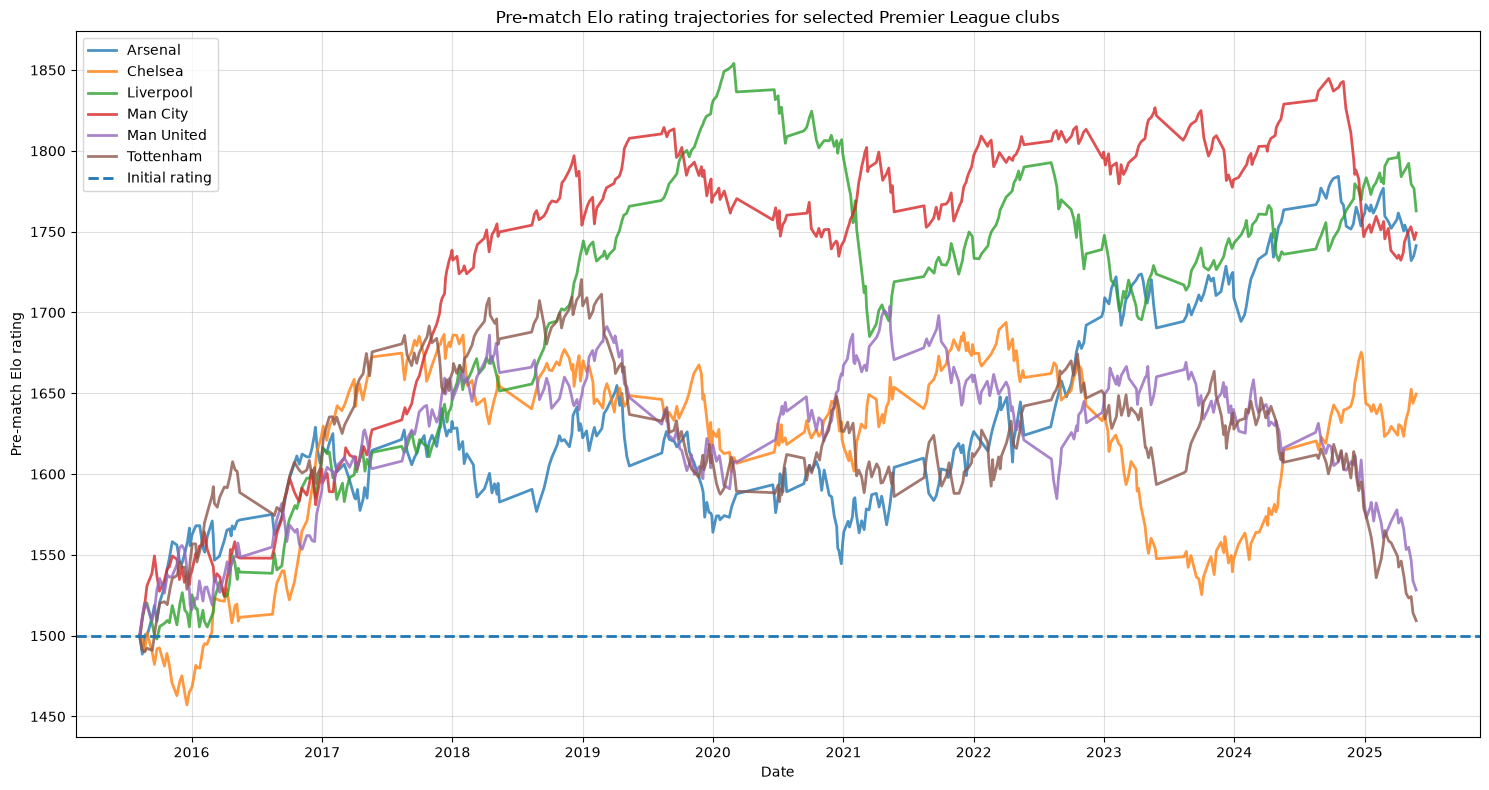

In [22]:
selected_teams = [
    "Arsenal",
    "Chelsea",
    "Liverpool",
    "Man City",
    "Man United",
    "Tottenham",
]

available_teams = set(elo_long["Team"].unique())
missing_selected_teams = [
    team
    for team in selected_teams
    if team not in available_teams
]

assert not missing_selected_teams, (
    f"Team names not found: {missing_selected_teams}"
)

plt.figure(figsize=(15, 8))

for team in selected_teams:
    team_history = elo_long.loc[
        elo_long["Team"] == team
    ].sort_values("Date")

    plt.plot(
        team_history["Date"],
        team_history["EloBefore"],
        label=team,
        linewidth=2,
        alpha=0.8,
    )

plt.axhline(
    initial_rating,
    linestyle="--",
    linewidth=2,
    label="Initial rating",
)

plt.title("Pre-match Elo rating trajectories for selected Premier League clubs")
plt.xlabel("Date")
plt.ylabel("Pre-match Elo rating")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretation

The selected teams exhibit smooth, path-dependent Elo trajectories over the ten-season period. Clubs that consistently performed at a high level, such as Manchester City and Liverpool, maintained ratings substantially above the initial value of $1500$, while periods of weaker performance are reflected by sustained declines.

The trajectories provide a qualitative validation that the Elo system captures long-term changes in team strength without producing implausible volatility. Although this visual inspection is encouraging, it does not constitute evidence of predictive performance. The predictive value of these features will be evaluated using probabilistic models in later chapters.

## Chapter 5 Summary

In this chapter, pre-match Elo ratings were generated for every Premier League fixture between the 2015–16 and 2024–25 seasons. The implementation reused the Elo framework developed in Notebook 1 while extending it to a ten-season dataset.

Key outcomes of this chapter include:

- Generation of point-in-time correct home and away Elo features.
- Validation that no target leakage was introduced during feature engineering.
- Successful chronological verification of the Elo state updates.
- Visual inspection of selected team trajectories, showing behaviour consistent with long-term team performance.

These Elo ratings provide the first quantitative features for the prediction model. The next chapter will extend the feature set with rolling measures of recent team performance, goals scored, goals conceded and other indicators of current form.

## 6. Creating recent-form features

Recent form measures a team's short-term performance before each fixture.

Unlike Elo, which represents accumulated long-term strength, rolling features summarise a fixed number of recent matches. These features may capture temporary changes in performance that are not yet fully reflected in the Elo rating.

Before calculating rolling statistics, the match-level dataset must be reshaped into a team-level history. Each fixture will generate two observations:

- one from the home team's perspective;
- one from the away team's perspective.

For every team appearance, the dataset will record:

- the match date;
- the team and opponent;
- whether the team played at home or away;
- goals scored;
- goals conceded;
- points earned.

### Notation

Throughout this chapter:

- $GF$ denotes **Goals For** (the number of goals scored by a team).
- $GA$ denotes **Goals Against** (the number of goals conceded by a team).
- $i$ denotes a particular team.
- $t$ denotes a particular match in chronological order.

The points earned by team $i$ in match $t$ are defined as

$$
P_{i,t}=
\begin{cases}
3, & GF_{i,t}>GA_{i,t},\\
1, & GF_{i,t}=GA_{i,t},\\
0, & GF_{i,t}<GA_{i,t}.
\end{cases}
$$

No rolling statistics are calculated at this stage. This section only creates the team-level structure required for subsequent point-in-time feature engineering.

In [23]:
# Create the home-team perspective
home_team_history = matches[
    [
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
    ]
].copy()

home_team_history = home_team_history.rename(
    columns={
        "HomeTeam": "Team",
        "AwayTeam": "Opponent",
        "FTHG": "GoalsFor",
        "FTAG": "GoalsAgainst",
    }
)

home_team_history["Venue"] = "Home"


# Create the away-team perspective
away_team_history = matches[
    [
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "FTHG",
        "FTAG",
    ]
].copy()

away_team_history = away_team_history.rename(
    columns={
        "AwayTeam": "Team",
        "HomeTeam": "Opponent",
        "FTAG": "GoalsFor",
        "FTHG": "GoalsAgainst",
    }
)

away_team_history["Venue"] = "Away"


# Combine both perspectives
team_history = pd.concat(
    [home_team_history, away_team_history],
    ignore_index=True,
)

# Convert each result into league points
team_history["Points"] = np.select(
    [
        team_history["GoalsFor"] > team_history["GoalsAgainst"],
        team_history["GoalsFor"] == team_history["GoalsAgainst"],
    ],
    [
        3,
        1,
    ],
    default=0,
)

# Restore chronological order for each team
team_history = (
    team_history
    .sort_values(["Team", "Date"])
    .reset_index(drop=True)
)

team_history.head(10)

,Season,Date,Team,Opponent,GoalsFor,GoalsAgainst,Venue,Points
0,2015-16,2015-08-09,Arsenal,West Ham,0,2,Home,0
1,2015-16,2015-08-16,Arsenal,Crystal Palace,2,1,Away,3
2,2015-16,2015-08-24,Arsenal,Liverpool,0,0,Home,1
3,2015-16,2015-08-29,Arsenal,Newcastle,1,0,Away,3
4,2015-16,2015-09-12,Arsenal,Stoke,2,0,Home,3
5,2015-16,2015-09-19,Arsenal,Chelsea,0,2,Away,0
6,2015-16,2015-09-26,Arsenal,Leicester,5,2,Away,3
7,2015-16,2015-10-04,Arsenal,Man United,3,0,Home,3
8,2015-16,2015-10-17,Arsenal,Watford,3,0,Away,3
9,2015-16,2015-10-24,Arsenal,Everton,2,1,Home,3


### 6.1 Validating the team-level history

Each original fixture should produce exactly two team observations.

The reshaped dataset should therefore contain $7600$ rows. Every observation must also have a valid points value from the set

$$
\{0,1,3\}.
$$

These checks confirm that the home and away perspectives were constructed consistently.

In [24]:
assert len(team_history) == 2 * len(matches)

assert team_history[
    [
        "Team",
        "Opponent",
        "GoalsFor",
        "GoalsAgainst",
        "Venue",
        "Points",
    ]
].notna().all().all()

assert set(team_history["Points"].unique()).issubset(
    {0, 1, 3}
)

assert set(team_history["Venue"].unique()) == {
    "Home",
    "Away",
}

print(f"Original matches: {len(matches)}")
print(f"Team observations: {len(team_history)}")
print("Team-level history created successfully.")

Original matches: 3800
Team observations: 7600
Team-level history created successfully.


### 6.2 Validating the team-level history

Before constructing rolling features, the team-level history must satisfy several structural assumptions.

For each team:

- there should be at most one Premier League fixture on any given date;
- every appearance should be represented exactly once;
- matches should be stored in chronological order.

If these conditions hold, the previous five matches,

$$
\{t-5,\ldots,t-1\},
$$

are uniquely defined for every fixture. This ensures that rolling statistics can be calculated consistently using only information available before kickoff.

In [25]:
# Ensure the team-level history is ordered correctly
team_history = (
    team_history
    .sort_values(["Team", "Date"])
    .reset_index(drop=True)
)

# Check for duplicate team appearances on the same date
duplicate_matches = (
    team_history
    .groupby(["Team", "Date"])
    .size()
    .reset_index(name="Count")
    .query("Count > 1")
)

# Identify any dates that move backwards within a team's history
previous_dates = (
    team_history
    .groupby("Team")["Date"]
    .shift(1)
)

out_of_order = team_history[
    team_history["Date"] < previous_dates
]

# Run validation checks
assert duplicate_matches.empty
assert out_of_order.empty

print(f"Teams checked: {team_history['Team'].nunique()}")
print("Duplicate team appearances: None")
print("Chronological ordering: Passed")

Teams checked: 34
Duplicate team appearances: None
Chronological ordering: Passed


#### Validation results

The team-level history passed all structural checks.

- No team appeared more than once on the same date.
- Each team's fixtures were stored in chronological order.
- The previous-match sequence is therefore uniquely defined for every team.

These results confirm that the dataset is suitable for rolling-window calculations. Any feature constructed from the previous $n$ observations will represent the team's actual previous $n$ league matches.

### 6.3 Rolling points over the previous five matches

The first recent-form feature measures the number of league points earned by each team across its previous five fixtures.

Let $P_{i,t}$ denote the points earned by team $i$ in match $t$. The rolling-points feature available before match $t$ is defined as

$$
RP5_{i,t}
=
\sum_{j=1}^{5} P_{i,t-j}.
$$

The current match is excluded from the calculation. This is essential because its result would not have been known before kickoff.

The feature therefore summarises the five matches

$$
\{t-5,\ldots,t-1\}.
$$

A full five-match window can range from $0$ points to $15$ points.

In [26]:
# Calculate points earned across the previous five matches
# within the same season
team_history["RollingPoints5"] = (
    team_history
    .groupby(["Team", "Season"])["Points"]
    .transform(
        lambda points: (
            points
            .shift(1)
            .rolling(window=5, min_periods=5)
            .sum()
        )
    )
)

team_history[
    [
        "Date",
        "Team",
        "Opponent",
        "Points",
        "RollingPoints5",
    ]
].head(10)

,Date,Team,Opponent,Points,RollingPoints5
0,2015-08-09,Arsenal,West Ham,0,NaN
1,2015-08-16,Arsenal,Crystal Palace,3,NaN
2,2015-08-24,Arsenal,Liverpool,1,NaN
3,2015-08-29,Arsenal,Newcastle,3,NaN
4,2015-09-12,Arsenal,Stoke,3,NaN
5,2015-09-19,Arsenal,Chelsea,0,10.0
6,2015-09-26,Arsenal,Leicester,3,10.0
7,2015-10-04,Arsenal,Man United,3,10.0
8,2015-10-17,Arsenal,Watford,3,12.0
9,2015-10-24,Arsenal,Everton,3,12.0


#### Interpretation

The `RollingPoints5` feature represents the total number of league points earned by a team across its five previous fixtures.

The first five appearances for each team contain missing values because a complete five-match history is not yet available. From the sixth appearance onwards, the feature takes values between

$$
0 \leq RP5_{i,t} \leq 15.
$$

A value near $15$ indicates very strong recent form, while a value near $0$ indicates that the team has earned few or no points in its previous five matches.

Because the points series was shifted by one match before applying the rolling window, the current fixture is excluded from the calculation. The feature is therefore point-in-time correct and does not introduce target leakage.

### 6.4 Validating the rolling-points feature

The rolling-points feature must use exactly the five fixtures preceding the current match.

The following checks verify that:

- the first five fixtures of every team-season have missing values because no complete rolling window is available;
- every later fixture has a rolling-points value;
- all complete values lie between $0$ and $15$;
- the first available value for a selected team-season equals the manually calculated sum of its previous five results.

These checks confirm that the current match has been excluded and that the feature is point-in-time correct.

In [27]:
# Number each fixture within its team-season
team_season_match_number = (
    team_history
    .groupby(["Team", "Season"])
    .cumcount()
    .add(1)
)

# The first five fixtures should not have a complete rolling window
assert team_history.loc[
    team_season_match_number <= 5,
    "RollingPoints5",
].isna().all()

# Every fixture after the first five should have a value
assert team_history.loc[
    team_season_match_number > 5,
    "RollingPoints5",
].notna().all()

# Every complete rolling-points value must be between 0 and 15
complete_rolling_points = team_history["RollingPoints5"].dropna()

assert complete_rolling_points.between(0, 15).all()


# Select the first available team-season for a manual audit
audit_team, audit_season = (
    team_history
    .groupby(["Team", "Season"])
    .size()
    .loc[lambda counts: counts >= 6]
    .index[0]
)

audit = (
    team_history[
        (team_history["Team"] == audit_team)
        & (team_history["Season"] == audit_season)
    ]
    .head(6)
    .copy()
)

manual_total = audit["Points"].iloc[:5].sum()
stored_total = audit["RollingPoints5"].iloc[5]

assert np.isclose(manual_total, stored_total)

print(f"Audited team: {audit_team}")
print(f"Audited season: {audit_season}")
print(f"Manual sum of first five matches: {manual_total}")
print(f"Stored value for sixth match: {stored_total}")
print("All rolling-points validation checks passed.")

audit[
    [
        "Date",
        "Team",
        "Opponent",
        "Points",
        "RollingPoints5",
    ]
]

Audited team: Arsenal
Audited season: 2015-16
Manual sum of first five matches: 10
Stored value for sixth match: 10.0
All rolling-points validation checks passed.


,Date,Team,Opponent,Points,RollingPoints5
0,2015-08-09,Arsenal,West Ham,0,NaN
1,2015-08-16,Arsenal,Crystal Palace,3,NaN
2,2015-08-24,Arsenal,Liverpool,1,NaN
3,2015-08-29,Arsenal,Newcastle,3,NaN
4,2015-09-12,Arsenal,Stoke,3,NaN
5,2015-09-19,Arsenal,Chelsea,0,10.0


#### Validation results

The rolling-points feature passed all validation checks.

The first five fixtures of every team-season correctly contain missing values, while subsequent fixtures contain a complete five-match rolling window. All available values fall within the theoretical range

$$
0 \leq RP5_{i,t} \leq 15.
$$

The manual audit also confirmed that the value stored for a team's sixth fixture equals the sum of the points earned in its first five fixtures. The current match is therefore excluded, and the feature does not introduce target leakage.

### 6.5 Merging rolling points into the match-level dataset

The rolling-points values are currently stored in the team-level history, where every fixture contributes one observation for each team.

To make these features available for modelling, the team-level values are separated into home and away lookup tables and merged back into the original match-level dataset.

For fixture $t$, the resulting features are:

- `HomeRollingPoints5`: points earned by the home team across its previous five league fixtures;
- `AwayRollingPoints5`: points earned by the away team across its previous five league fixtures.

The merge uses the season, date, home team and away team to identify each fixture. A left join preserves every original match, including early-season fixtures for which a complete five-match history is unavailable.

In [28]:
# Create a lookup table for the home team's rolling points
home_rolling_points = (
    team_history.loc[
        team_history["Venue"] == "Home",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            "RollingPoints5",
        ],
    ]
    .rename(
        columns={
            "Team": "HomeTeam",
            "Opponent": "AwayTeam",
            "RollingPoints5": "HomeRollingPoints5",
        }
    )
)

# Create a lookup table for the away team's rolling points
away_rolling_points = (
    team_history.loc[
        team_history["Venue"] == "Away",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            "RollingPoints5",
        ],
    ]
    .rename(
        columns={
            "Team": "AwayTeam",
            "Opponent": "HomeTeam",
            "RollingPoints5": "AwayRollingPoints5",
        }
    )
)

# Make the cell safe to rerun
rolling_feature_columns = [
    "HomeRollingPoints5",
    "AwayRollingPoints5",
]

matches = matches.drop(
    columns=[
        column
        for column in rolling_feature_columns
        if column in matches.columns
    ]
)

original_match_count = len(matches)

# Merge the home-team feature
matches = matches.merge(
    home_rolling_points,
    on=[
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
    ],
    how="left",
    validate="one_to_one",
)

# Merge the away-team feature
matches = matches.merge(
    away_rolling_points,
    on=[
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
    ],
    how="left",
    validate="one_to_one",
)

# Confirm that the merge preserved every original fixture
assert len(matches) == original_match_count

# Confirm that every non-missing value lies in the valid range
assert matches["HomeRollingPoints5"].dropna().between(0, 15).all()
assert matches["AwayRollingPoints5"].dropna().between(0, 15).all()

# Confirm that the number of missing values matches the
# incomplete rolling windows in the team-level history
expected_missing_values = (
    team_history["RollingPoints5"]
    .isna()
    .sum()
)

merged_missing_values = (
    matches["HomeRollingPoints5"].isna().sum()
    + matches["AwayRollingPoints5"].isna().sum()
)

assert merged_missing_values == expected_missing_values

print(f"Match rows before merge: {original_match_count}")
print(f"Match rows after merge: {len(matches)}")
print(f"Expected missing rolling values: {expected_missing_values}")
print(f"Merged missing rolling values: {merged_missing_values}")
print("Rolling-points features merged successfully.")

matches[
    [
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "HomeRollingPoints5",
        "AwayRollingPoints5",
    ]
].head(12)

Match rows before merge: 3800
Match rows after merge: 3800
Expected missing rolling values: 1000
Merged missing rolling values: 1000
Rolling-points features merged successfully.


,Season,Date,HomeTeam,AwayTeam,HomeRollingPoints5,AwayRollingPoints5
0,2015-16,2015-08-08,Bournemouth,Aston Villa,NaN,NaN
1,2015-16,2015-08-08,Chelsea,Swansea,NaN,NaN
2,2015-16,2015-08-08,Everton,Watford,NaN,NaN
3,2015-16,2015-08-08,Leicester,Sunderland,NaN,NaN
4,2015-16,2015-08-08,Man United,Tottenham,NaN,NaN
5,2015-16,2015-08-08,Norwich,Crystal Palace,NaN,NaN
6,2015-16,2015-08-09,Arsenal,West Ham,NaN,NaN
7,2015-16,2015-08-09,Newcastle,Southampton,NaN,NaN
8,2015-16,2015-08-09,Stoke,Liverpool,NaN,NaN
9,2015-16,2015-08-10,West Brom,Man City,NaN,NaN


#### Merge validation results

The rolling-points features were successfully merged into the match-level dataset.

The merge preserved all original fixtures and produced one home and one away rolling-points feature for each match. All complete values lie within the theoretical range

$$
0 \leq RP5_{i,t} \leq 15.
$$

The remaining missing values correspond exclusively to the first five fixtures of each team-season, where a complete five-match rolling window is unavailable.

The modelling dataset now contains point-in-time measures of recent form for both the home and away teams.

### 6.6 Additional five-match form features

Rolling points summarise recent results but do not distinguish between attacking and defensive performance.

To provide a more detailed representation of recent form, four additional features are constructed using each team's previous five fixtures:

- goals scored;
- goals conceded;
- goal difference;
- win rate.

Let $GF_{i,t}$ and $GA_{i,t}$ denote the goals scored and conceded by team $i$ in match $t$. Let $W_{i,t}$ equal $1$ if the team wins and $0$ otherwise.

The rolling goals-scored feature is

$$
RGF5_{i,t}
=
\sum_{j=1}^{5} GF_{i,t-j}.
$$

The rolling goals-conceded feature is

$$
RGA5_{i,t}
=
\sum_{j=1}^{5} GA_{i,t-j}.
$$

Recent goal difference is defined as

$$
RGD5_{i,t}
=
RGF5_{i,t}-RGA5_{i,t}.
$$

The five-match win rate is

$$
WR5_{i,t}
=
\frac{1}{5}
\sum_{j=1}^{5} W_{i,t-j}.
$$

As with rolling points, all calculations are performed separately within each team-season and exclude the current fixture.

In [29]:
# Record whether each team won its current match
team_history["Win"] = (
    team_history["Points"] == 3
).astype(int)


def previous_five_sum(values):
    """
    Calculate the sum of the previous five observations,
    excluding the current observation.
    """
    return (
        values
        .shift(1)
        .rolling(window=5, min_periods=5)
        .sum()
    )


def previous_five_mean(values):
    """
    Calculate the mean of the previous five observations,
    excluding the current observation.
    """
    return (
        values
        .shift(1)
        .rolling(window=5, min_periods=5)
        .mean()
    )


# Group observations separately within each team-season
team_season_groups = team_history.groupby(
    ["Team", "Season"],
    sort=False,
)

# Recent attacking performance
team_history["RollingGoalsFor5"] = (
    team_season_groups["GoalsFor"]
    .transform(previous_five_sum)
)

# Recent defensive performance
team_history["RollingGoalsAgainst5"] = (
    team_season_groups["GoalsAgainst"]
    .transform(previous_five_sum)
)

# Recent win frequency
team_history["RollingWinRate5"] = (
    team_season_groups["Win"]
    .transform(previous_five_mean)
)

# Recent goal difference
team_history["RollingGoalDifference5"] = (
    team_history["RollingGoalsFor5"]
    - team_history["RollingGoalsAgainst5"]
)

team_history[
    [
        "Season",
        "Date",
        "Team",
        "Opponent",
        "GoalsFor",
        "GoalsAgainst",
        "Win",
        "RollingGoalsFor5",
        "RollingGoalsAgainst5",
        "RollingGoalDifference5",
        "RollingWinRate5",
    ]
].head(10)

,Season,Date,Team,Opponent,GoalsFor,GoalsAgainst,Win,RollingGoalsFor5,RollingGoalsAgainst5,RollingGoalDifference5,RollingWinRate5
0,2015-16,2015-08-09,Arsenal,West Ham,0,2,0,NaN,NaN,NaN,NaN
1,2015-16,2015-08-16,Arsenal,Crystal Palace,2,1,1,NaN,NaN,NaN,NaN
2,2015-16,2015-08-24,Arsenal,Liverpool,0,0,0,NaN,NaN,NaN,NaN
3,2015-16,2015-08-29,Arsenal,Newcastle,1,0,1,NaN,NaN,NaN,NaN
4,2015-16,2015-09-12,Arsenal,Stoke,2,0,1,NaN,NaN,NaN,NaN
5,2015-16,2015-09-19,Arsenal,Chelsea,0,2,0,5.0,3.0,2.0,0.6
6,2015-16,2015-09-26,Arsenal,Leicester,5,2,1,5.0,3.0,2.0,0.6
7,2015-16,2015-10-04,Arsenal,Man United,3,0,1,8.0,4.0,4.0,0.6
8,2015-16,2015-10-17,Arsenal,Watford,3,0,1,11.0,4.0,7.0,0.8
9,2015-16,2015-10-24,Arsenal,Everton,2,1,1,13.0,4.0,9.0,0.8


### 6.7 Validating the additional form features

The additional rolling-form features must represent exactly the five fixtures preceding the current match.

The following checks verify that:

- the first five fixtures of every team-season contain missing values;
- every subsequent fixture contains complete rolling features;
- goals scored and conceded are non-negative;
- win rates lie between $0$ and $1$;
- goal difference equals rolling goals scored minus rolling goals conceded;
- the first complete rolling window matches a manual calculation.

These checks ensure that the features are internally consistent, point-in-time correct and free from target leakage.

In [30]:
rolling_form_columns = [
    "RollingGoalsFor5",
    "RollingGoalsAgainst5",
    "RollingGoalDifference5",
    "RollingWinRate5",
]

# Number each fixture within its team-season
team_season_match_number = (
    team_history
    .groupby(["Team", "Season"])
    .cumcount()
    .add(1)
)

# The first five fixtures should have incomplete rolling windows
assert team_history.loc[
    team_season_match_number <= 5,
    rolling_form_columns,
].isna().all().all()

# Every fixture after the first five should have complete values
assert team_history.loc[
    team_season_match_number > 5,
    rolling_form_columns,
].notna().all().all()

# Goals scored and conceded must be non-negative
assert team_history["RollingGoalsFor5"].dropna().ge(0).all()
assert team_history["RollingGoalsAgainst5"].dropna().ge(0).all()

# Win rates must lie between 0 and 1
assert team_history["RollingWinRate5"].dropna().between(0, 1).all()

# Win rates should be multiples of 0.2
scaled_win_rates = (
    team_history["RollingWinRate5"]
    .dropna()
    .mul(5)
)

assert np.allclose(
    scaled_win_rates,
    scaled_win_rates.round(),
)

# Goal difference must equal goals scored minus goals conceded
expected_goal_difference = (
    team_history["RollingGoalsFor5"]
    - team_history["RollingGoalsAgainst5"]
)

complete_goal_difference = (
    team_history["RollingGoalDifference5"].notna()
)

assert np.allclose(
    team_history.loc[
        complete_goal_difference,
        "RollingGoalDifference5",
    ],
    expected_goal_difference.loc[
        complete_goal_difference
    ],
)


# Select one team-season for a manual audit
audit_team, audit_season = (
    team_history
    .groupby(["Team", "Season"])
    .size()
    .loc[lambda counts: counts >= 6]
    .index[0]
)

audit = (
    team_history[
        (team_history["Team"] == audit_team)
        & (team_history["Season"] == audit_season)
    ]
    .head(6)
    .copy()
)

# Manually calculate the first complete rolling window
manual_goals_for = audit["GoalsFor"].iloc[:5].sum()
manual_goals_against = audit["GoalsAgainst"].iloc[:5].sum()
manual_goal_difference = (
    manual_goals_for - manual_goals_against
)
manual_win_rate = audit["Win"].iloc[:5].mean()

# Retrieve the stored values for the sixth fixture
stored_goals_for = audit["RollingGoalsFor5"].iloc[5]
stored_goals_against = audit["RollingGoalsAgainst5"].iloc[5]
stored_goal_difference = audit["RollingGoalDifference5"].iloc[5]
stored_win_rate = audit["RollingWinRate5"].iloc[5]

# Compare the manual and stored values
assert np.isclose(
    manual_goals_for,
    stored_goals_for,
)

assert np.isclose(
    manual_goals_against,
    stored_goals_against,
)

assert np.isclose(
    manual_goal_difference,
    stored_goal_difference,
)

assert np.isclose(
    manual_win_rate,
    stored_win_rate,
)

print(f"Audited team: {audit_team}")
print(f"Audited season: {audit_season}")
print()
print(f"Manual rolling goals for: {manual_goals_for}")
print(f"Stored rolling goals for: {stored_goals_for}")
print()
print(f"Manual rolling goals against: {manual_goals_against}")
print(f"Stored rolling goals against: {stored_goals_against}")
print()
print(f"Manual rolling goal difference: {manual_goal_difference}")
print(f"Stored rolling goal difference: {stored_goal_difference}")
print()
print(f"Manual rolling win rate: {manual_win_rate:.1f}")
print(f"Stored rolling win rate: {stored_win_rate:.1f}")
print()
print("All additional rolling-form validation checks passed.")

audit[
    [
        "Date",
        "Team",
        "Opponent",
        "GoalsFor",
        "GoalsAgainst",
        "Win",
        "RollingGoalsFor5",
        "RollingGoalsAgainst5",
        "RollingGoalDifference5",
        "RollingWinRate5",
    ]
]

Audited team: Arsenal
Audited season: 2015-16

Manual rolling goals for: 5
Stored rolling goals for: 5.0

Manual rolling goals against: 3
Stored rolling goals against: 3.0

Manual rolling goal difference: 2
Stored rolling goal difference: 2.0

Manual rolling win rate: 0.6
Stored rolling win rate: 0.6

All additional rolling-form validation checks passed.


,Date,Team,Opponent,GoalsFor,GoalsAgainst,Win,RollingGoalsFor5,RollingGoalsAgainst5,RollingGoalDifference5,RollingWinRate5
0,2015-08-09,Arsenal,West Ham,0,2,0,NaN,NaN,NaN,NaN
1,2015-08-16,Arsenal,Crystal Palace,2,1,1,NaN,NaN,NaN,NaN
2,2015-08-24,Arsenal,Liverpool,0,0,0,NaN,NaN,NaN,NaN
3,2015-08-29,Arsenal,Newcastle,1,0,1,NaN,NaN,NaN,NaN
4,2015-09-12,Arsenal,Stoke,2,0,1,NaN,NaN,NaN,NaN
5,2015-09-19,Arsenal,Chelsea,0,2,0,5.0,3.0,2.0,0.6


#### Validation results

All additional five-match form features passed the structural and manual validation checks.

The first five fixtures of each team-season correctly contain missing values, while later fixtures contain complete rolling windows. Rolling goals scored and conceded are non-negative, win rates lie within the interval

$$
0 \leq WR5_{i,t} \leq 1,
$$

and rolling goal difference is consistent with

$$
RGD5_{i,t}
=
RGF5_{i,t}-RGA5_{i,t}.
$$

The manual audit confirmed that the first available values were calculated using only the preceding five fixtures. The features are therefore point-in-time correct and do not use information from the current match.

### 6.8 Merging the additional form features

The additional recent-form features are currently stored in the team-level history.

To make them available for modelling, the home and away observations are separated and merged back into the match-level dataset. Each fixture receives eight new variables:

- rolling goals scored for the home and away teams;
- rolling goals conceded for the home and away teams;
- rolling goal difference for the home and away teams;
- rolling win rate for the home and away teams.

The merge uses the season, date, home team and away team to identify each fixture. One-to-one merge validation is used to ensure that no fixture is duplicated.

In [31]:
# Features to transfer from the team-level history
additional_form_columns = [
    "RollingGoalsFor5",
    "RollingGoalsAgainst5",
    "RollingGoalDifference5",
    "RollingWinRate5",
]

merge_keys = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
]


# Create the home-team lookup table
home_additional_form = (
    team_history.loc[
        team_history["Venue"] == "Home",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            *additional_form_columns,
        ],
    ]
    .rename(
        columns={
            "Team": "HomeTeam",
            "Opponent": "AwayTeam",
            "RollingGoalsFor5": "HomeRollingGoalsFor5",
            "RollingGoalsAgainst5": "HomeRollingGoalsAgainst5",
            "RollingGoalDifference5": "HomeRollingGoalDifference5",
            "RollingWinRate5": "HomeRollingWinRate5",
        }
    )
)


# Create the away-team lookup table
away_additional_form = (
    team_history.loc[
        team_history["Venue"] == "Away",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            *additional_form_columns,
        ],
    ]
    .rename(
        columns={
            "Team": "AwayTeam",
            "Opponent": "HomeTeam",
            "RollingGoalsFor5": "AwayRollingGoalsFor5",
            "RollingGoalsAgainst5": "AwayRollingGoalsAgainst5",
            "RollingGoalDifference5": "AwayRollingGoalDifference5",
            "RollingWinRate5": "AwayRollingWinRate5",
        }
    )
)


# Make the cell safe to rerun
new_match_columns = [
    "HomeRollingGoalsFor5",
    "AwayRollingGoalsFor5",
    "HomeRollingGoalsAgainst5",
    "AwayRollingGoalsAgainst5",
    "HomeRollingGoalDifference5",
    "AwayRollingGoalDifference5",
    "HomeRollingWinRate5",
    "AwayRollingWinRate5",
]

matches = matches.drop(
    columns=[
        column
        for column in new_match_columns
        if column in matches.columns
    ]
)

original_match_count = len(matches)


# Merge the home-team features
matches = matches.merge(
    home_additional_form,
    on=merge_keys,
    how="left",
    validate="one_to_one",
)


# Merge the away-team features
matches = matches.merge(
    away_additional_form,
    on=merge_keys,
    how="left",
    validate="one_to_one",
)


# Confirm that no fixtures were added or removed
assert len(matches) == original_match_count


# Validate the ranges of the merged features
assert matches["HomeRollingGoalsFor5"].dropna().ge(0).all()
assert matches["AwayRollingGoalsFor5"].dropna().ge(0).all()

assert matches["HomeRollingGoalsAgainst5"].dropna().ge(0).all()
assert matches["AwayRollingGoalsAgainst5"].dropna().ge(0).all()

assert matches["HomeRollingWinRate5"].dropna().between(0, 1).all()
assert matches["AwayRollingWinRate5"].dropna().between(0, 1).all()


# Confirm that rolling goal difference remains internally consistent
home_complete = matches["HomeRollingGoalDifference5"].notna()
away_complete = matches["AwayRollingGoalDifference5"].notna()

assert np.allclose(
    matches.loc[
        home_complete,
        "HomeRollingGoalDifference5",
    ],
    (
        matches.loc[home_complete, "HomeRollingGoalsFor5"]
        - matches.loc[home_complete, "HomeRollingGoalsAgainst5"]
    ),
)

assert np.allclose(
    matches.loc[
        away_complete,
        "AwayRollingGoalDifference5",
    ],
    (
        matches.loc[away_complete, "AwayRollingGoalsFor5"]
        - matches.loc[away_complete, "AwayRollingGoalsAgainst5"]
    ),
)


# Reconcile the missing values with the team-level history
expected_missing_per_feature = (
    team_history["RollingGoalsFor5"]
    .isna()
    .sum()
)

for home_column, away_column in [
    ("HomeRollingGoalsFor5", "AwayRollingGoalsFor5"),
    ("HomeRollingGoalsAgainst5", "AwayRollingGoalsAgainst5"),
    (
        "HomeRollingGoalDifference5",
        "AwayRollingGoalDifference5",
    ),
    ("HomeRollingWinRate5", "AwayRollingWinRate5"),
]:
    merged_missing = (
        matches[home_column].isna().sum()
        + matches[away_column].isna().sum()
    )

    assert merged_missing == expected_missing_per_feature


print(f"Match rows before merge: {original_match_count}")
print(f"Match rows after merge: {len(matches)}")
print(
    "Expected missing values per home-away feature pair:",
    expected_missing_per_feature,
)
print("Additional rolling-form features merged successfully.")


matches[
    [
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "HomeRollingPoints5",
        "AwayRollingPoints5",
        "HomeRollingGoalsFor5",
        "AwayRollingGoalsFor5",
        "HomeRollingGoalsAgainst5",
        "AwayRollingGoalsAgainst5",
        "HomeRollingGoalDifference5",
        "AwayRollingGoalDifference5",
        "HomeRollingWinRate5",
        "AwayRollingWinRate5",
    ]
].head(12)

Match rows before merge: 3800
Match rows after merge: 3800
Expected missing values per home-away feature pair: 1000
Additional rolling-form features merged successfully.


,Season,Date,HomeTeam,AwayTeam,HomeRollingPoints5,AwayRollingPoints5,HomeRollingGoalsFor5,AwayRollingGoalsFor5,HomeRollingGoalsAgainst5,AwayRollingGoalsAgainst5,HomeRollingGoalDifference5,AwayRollingGoalDifference5,HomeRollingWinRate5,AwayRollingWinRate5
0,2015-16,2015-08-08,Bournemouth,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-16,2015-08-08,Chelsea,Swansea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-16,2015-08-08,Everton,Watford,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-16,2015-08-08,Leicester,Sunderland,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-16,2015-08-08,Man United,Tottenham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2015-16,2015-08-08,Norwich,Crystal Palace,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2015-16,2015-08-09,Arsenal,West Ham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2015-16,2015-08-09,Newcastle,Southampton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2015-16,2015-08-09,Stoke,Liverpool,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2015-16,2015-08-10,West Brom,Man City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Merge validation results

The additional recent-form features were successfully merged into the match-level dataset.

All 3,800 fixtures were preserved, and every available feature remained within its valid range. The goal-difference variables also retained the identity

$$
RGD5_{i,t}
=
RGF5_{i,t}-RGA5_{i,t}.
$$

The missing values reconcile exactly with the incomplete five-match windows in the team-level history. Therefore, no observations were lost or incorrectly matched during the merge.

The modelling dataset now contains separate point-in-time measures of recent attacking performance, defensive performance, goal difference and win frequency for both teams in each fixture.

### 6.9 Visualising recent-form features

#### 6.9.1 Five-match rolling-points trajectories

A visual diagnostic is used to examine how the rolling-points feature evolves through time.

Plotting every club simultaneously would make individual trajectories difficult to interpret. Therefore, six clubs that participated in all ten seasons are selected for the visualisation:

- Arsenal;
- Chelsea;
- Liverpool;
- Manchester City;
- Manchester United;
- Tottenham.

For team $i$ before match $t$, the plotted feature is

$$
RP5_{i,t}
=
\sum_{j=1}^{5}P_{i,t-j}.
$$

The feature ranges between $0$ and $15$. Higher values indicate stronger recent results, while lower values indicate weaker recent form.

The selected teams are used only for visual clarity. Features have been calculated for every club in the dataset.

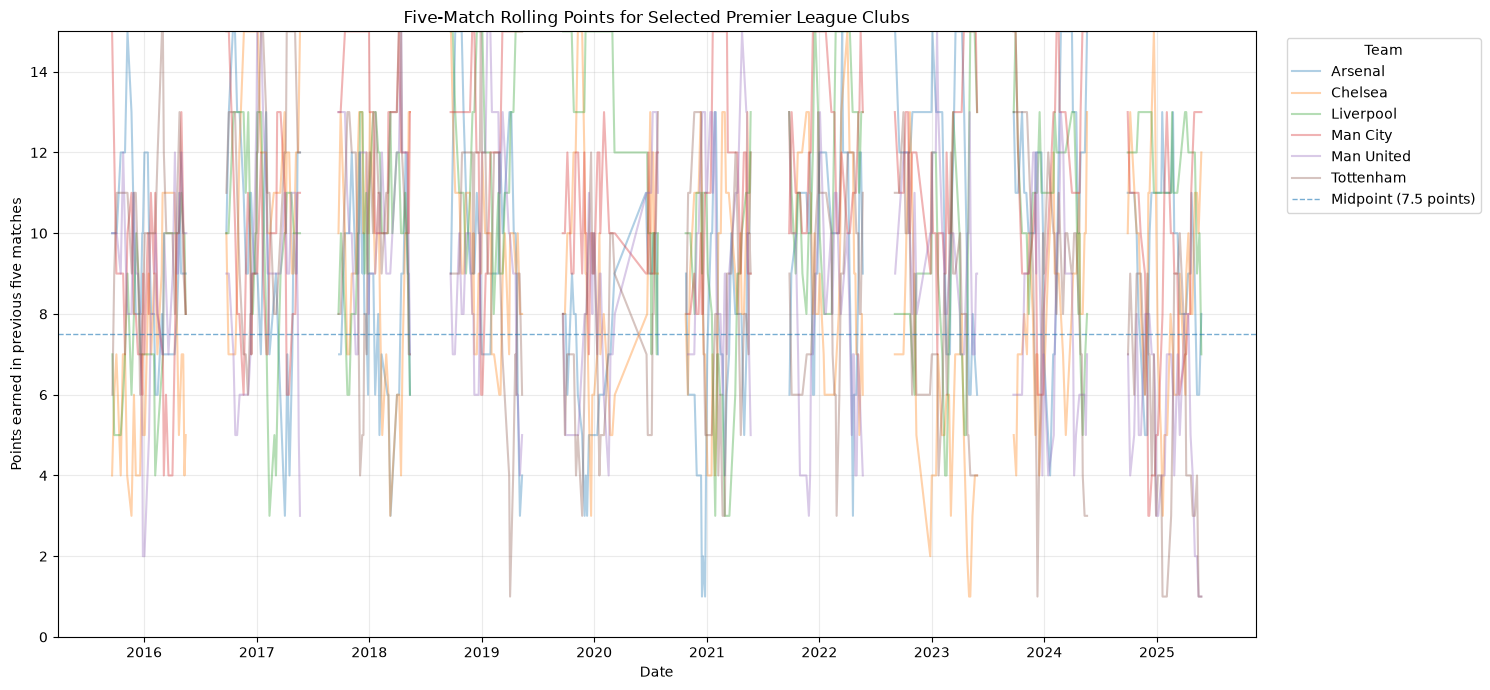

In [38]:
selected_teams = [
    "Arsenal",
    "Chelsea",
    "Liverpool",
    "Man City",
    "Man United",
    "Tottenham",
]

rolling_points_plot = (
    team_history.loc[
        team_history["Team"].isin(selected_teams),
        [
            "Date",
            "Team",
            "RollingPoints5",
        ],
    ]
    .sort_values(["Team", "Date"])
)

plt.figure(figsize=(15, 7))

for team in selected_teams:
    team_data = rolling_points_plot[
        rolling_points_plot["Team"] == team
    ]

    plt.plot(
        team_data["Date"],
        team_data["RollingPoints5"],
        label=team,
        linewidth=1.5,
        alpha=0.35,
    )

plt.axhline(
    y=7.5,
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label="Midpoint (7.5 points)",
)

plt.title(
    "Five-Match Rolling Points for Selected Premier League Clubs"
)
plt.xlabel("Date")
plt.ylabel("Points earned in previous five matches")
plt.ylim(0, 15)
plt.legend(
    title="Team",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Interpretation

The five-match rolling-points trajectories show substantial short-term variation across the selected clubs. This is expected because the feature uses only the five fixtures immediately preceding each match.

A sequence of strong results produces a rapid increase in `RollingPoints5`, while a poor run causes the feature to decline quickly. The measure is therefore considerably more responsive than Elo, which changes gradually and represents longer-term team strength.

The gaps near the beginning of each season are intentional. The rolling calculation resets at each season boundary, so the first five fixtures of every team-season do not have a complete five-match history.

After correcting the mixed date-format issue, the trajectories now cover all ten seasons, including 2016–17, in the correct chronological order.

The visualisation confirms that the feature behaves consistently with football intuition:

- values remain within the theoretical range of $0$ to $15$;
- strong runs are represented by higher rolling-points values;
- weak runs are represented by lower values;
- the feature reacts rapidly when recent performance changes.

However, the density and volatility of the trajectories make precise comparisons difficult over a ten-season period. The plot is therefore primarily a qualitative validation tool. Whole-dataset distributions will provide a clearer assessment of the range, frequency and concentration of the recent-form features.

#### 6.9.2 Distribution of five-match rolling points

The trajectory plot demonstrates that recent form changes through time, but the overlapping team paths make the overall feature distribution difficult to assess.

A frequency distribution is therefore constructed using every valid team appearance across all ten seasons.

For team $i$ before fixture $t$, five-match rolling points are defined as

$$
RP5_{i,t}
=
\sum_{j=1}^{5}P_{i,t-j},
$$

where

$$
P_{i,t-j}\in\{0,1,3\}.
$$

The theoretical range is therefore

$$
0\leq RP5_{i,t}\leq15.
$$

The relative frequency of value $r$ is

$$
\hat{p}(r)
=
\frac{
\#\{RP5_{i,t}=r\}
}{
N
},
$$

where $N$ is the total number of valid rolling-window observations.

Although the feature ranges from $0$ to $15$, a value of $14$ is mathematically impossible. Five wins produce $15$ points, while replacing one win with a draw or loss reduces the total to $13$ or $12$, respectively.

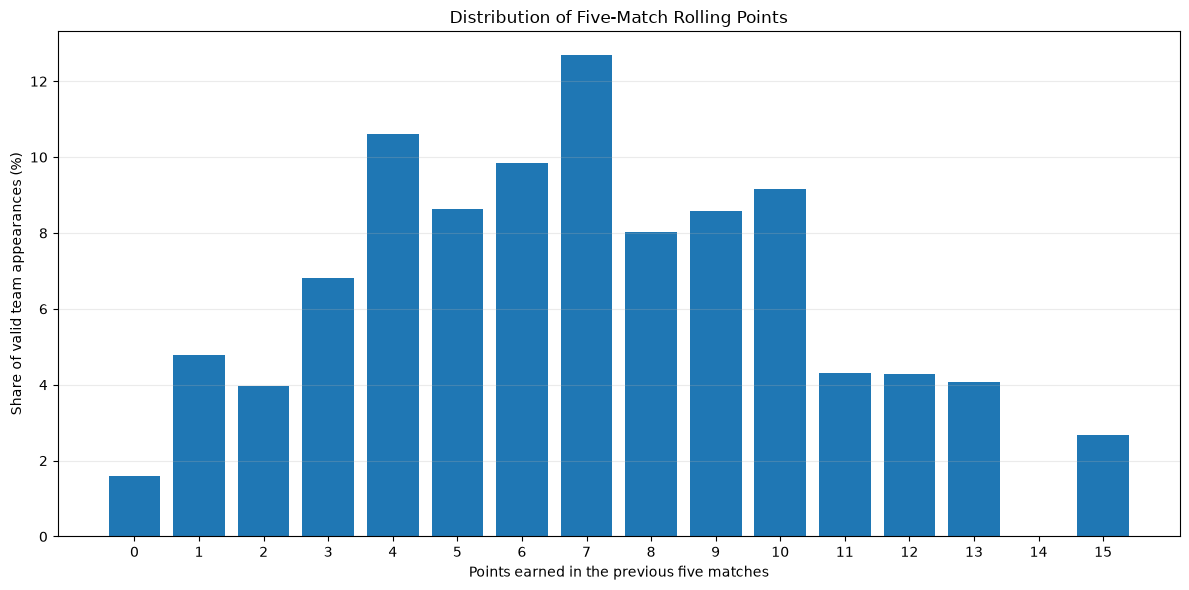

Valid observations: 6,600
Mean: 6.91
Median: 7.00
Mode: 7


,Count,Percentage
RollingPoints5,,
0,105,1.59
1,315,4.77
2,261,3.95
3,450,6.82
4,701,10.62
5,570,8.64
6,649,9.83
7,837,12.68
8,529,8.02


In [39]:
# Extract complete five-match rolling-points observations
rolling_points_values = (
    team_history["RollingPoints5"]
    .dropna()
    .astype(int)
)

# Count every possible value from 0 to 15
rolling_points_frequency = (
    rolling_points_values
    .value_counts()
    .reindex(range(16), fill_value=0)
    .sort_index()
)

# Convert counts into percentages
rolling_points_percentage = (
    100
    * rolling_points_frequency
    / rolling_points_frequency.sum()
)

rolling_points_distribution = pd.DataFrame(
    {
        "Count": rolling_points_frequency,
        "Percentage": rolling_points_percentage,
    }
)

# Validate the distribution
assert rolling_points_frequency.sum() == rolling_points_values.shape[0]
assert rolling_points_frequency.index.min() == 0
assert rolling_points_frequency.index.max() == 15

# Fourteen points cannot be obtained from five results
assert rolling_points_frequency.loc[14] == 0

# Plot the whole-dataset distribution
plt.figure(figsize=(12, 6))

plt.bar(
    rolling_points_distribution.index,
    rolling_points_distribution["Percentage"],
)

plt.title(
    "Distribution of Five-Match Rolling Points"
)
plt.xlabel(
    "Points earned in the previous five matches"
)
plt.ylabel(
    "Share of valid team appearances (%)"
)

plt.xticks(range(16))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(
    f"Valid observations: "
    f"{len(rolling_points_values):,}"
)
print(
    f"Mean: "
    f"{rolling_points_values.mean():.2f}"
)
print(
    f"Median: "
    f"{rolling_points_values.median():.2f}"
)
print(
    f"Mode: "
    f"{rolling_points_values.mode().iloc[0]}"
)

rolling_points_distribution.round(
    {"Percentage": 2}
)

#### Interpretation

The distribution provides a clearer whole-dataset view of recent performance than the individual team trajectories.

Most observations are concentrated around intermediate points totals, while extremely weak and extremely strong five-match sequences occur less frequently. This is consistent with the expectation that prolonged losing and winning runs are less common than mixed sequences of wins, draws and losses.

The absence of observations at $14$ points is mathematically correct rather than a data-quality problem. A team can earn $15$ points from five wins or $13$ points from four wins and one draw, but no combination of five results produces exactly $14$ points.

The feature therefore satisfies both its theoretical range and its discrete scoring structure. Its variation across the full dataset suggests that it can distinguish between teams entering fixtures with different levels of recent results.

Whether this variation improves forecast accuracy will be assessed through out-of-sample model evaluation rather than inferred from the distribution alone.

#### 6.9.3 Distributions of five-match goals scored and conceded

Recent attacking and defensive performance are represented by the total numbers of goals scored and conceded during the five fixtures preceding each match.

For team $i$ before fixture $t$, these features are defined as

$$
RGF5_{i,t}
=
\sum_{j=1}^{5}GF_{i,t-j},
$$

and

$$
RGA5_{i,t}
=
\sum_{j=1}^{5}GA_{i,t-j}.
$$

Both variables are non-negative integers. Unlike five-match rolling points, they do not have a small fixed theoretical upper bound, although very large values should occur infrequently.

Separate frequency distributions are plotted using identical integer bins and axis limits. This allows recent attacking output and defensive vulnerability to be compared without combining two overlapping distributions into a single figure.

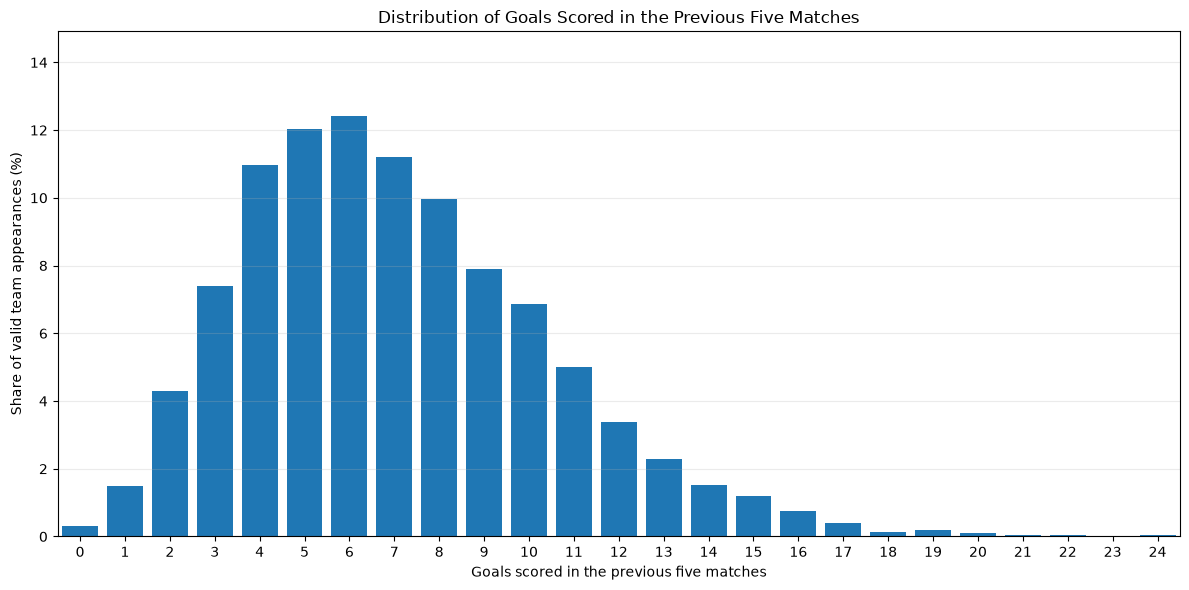

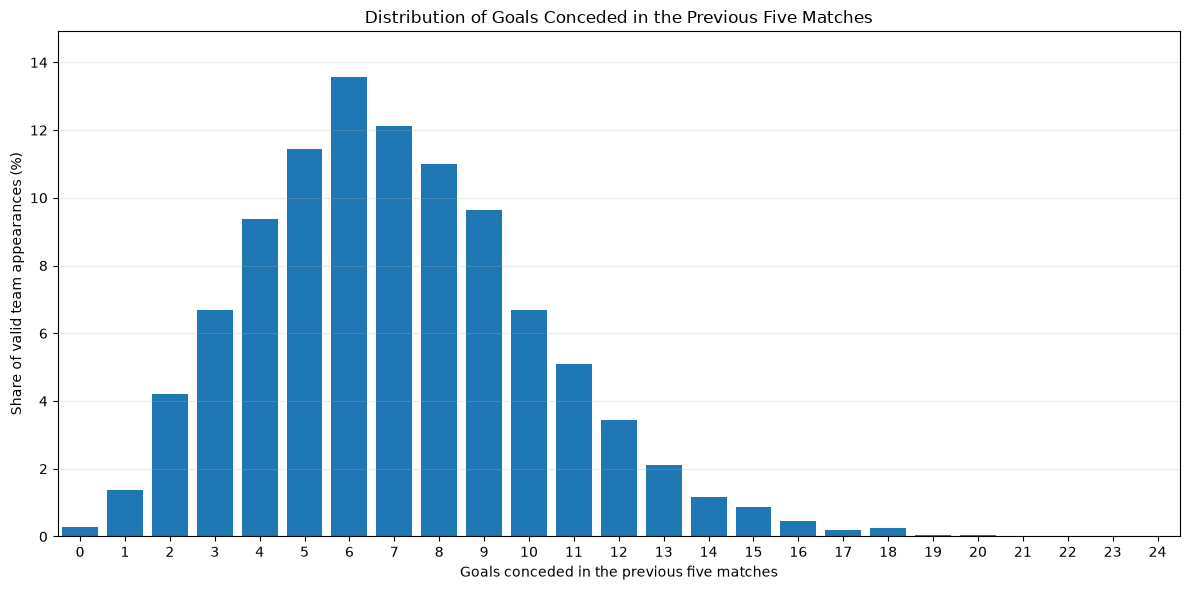

Valid observations per feature: 6,600
Rolling goals scored skewness: 0.718
Rolling goals conceded skewness: 0.496


,RollingGoalsFor5,RollingGoalsAgainst5
count,6600.00,6600.00
mean,7.04,7.03
std,3.39,3.13
min,0.00,0.00
25%,5.00,5.00
50%,7.00,7.00
75%,9.00,9.00
max,24.00,20.00


In [40]:
# Extract complete rolling-goals observations
rolling_goals_for = (
    team_history["RollingGoalsFor5"]
    .dropna()
)

rolling_goals_against = (
    team_history["RollingGoalsAgainst5"]
    .dropna()
)


# Validate the feature values
assert rolling_goals_for.ge(0).all()
assert rolling_goals_against.ge(0).all()

assert np.allclose(
    rolling_goals_for,
    rolling_goals_for.round(),
)

assert np.allclose(
    rolling_goals_against,
    rolling_goals_against.round(),
)


# Convert to integers after validation
rolling_goals_for = rolling_goals_for.astype(int)
rolling_goals_against = rolling_goals_against.astype(int)


# Both features should contain the same number of valid observations
assert len(rolling_goals_for) == len(rolling_goals_against)


# Use a common range so the two plots are directly comparable
maximum_goal_total = int(
    max(
        rolling_goals_for.max(),
        rolling_goals_against.max(),
    )
)

goal_values = np.arange(
    0,
    maximum_goal_total + 1,
)

goals_for_frequency = (
    rolling_goals_for
    .value_counts()
    .reindex(goal_values, fill_value=0)
    .sort_index()
)

goals_against_frequency = (
    rolling_goals_against
    .value_counts()
    .reindex(goal_values, fill_value=0)
    .sort_index()
)


# Convert counts into percentages
goals_for_percentage = (
    100
    * goals_for_frequency
    / goals_for_frequency.sum()
)

goals_against_percentage = (
    100
    * goals_against_frequency
    / goals_against_frequency.sum()
)


# Use the same vertical scale for both plots
shared_y_limit = 1.1 * max(
    goals_for_percentage.max(),
    goals_against_percentage.max(),
)


# Plot rolling goals scored
plt.figure(figsize=(12, 6))

plt.bar(
    goal_values,
    goals_for_percentage,
)

plt.title(
    "Distribution of Goals Scored in the Previous Five Matches"
)
plt.xlabel(
    "Goals scored in the previous five matches"
)
plt.ylabel(
    "Share of valid team appearances (%)"
)

plt.xticks(goal_values)
plt.xlim(-0.5, maximum_goal_total + 0.5)
plt.ylim(0, shared_y_limit)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# Plot rolling goals conceded
plt.figure(figsize=(12, 6))

plt.bar(
    goal_values,
    goals_against_percentage,
)

plt.title(
    "Distribution of Goals Conceded in the Previous Five Matches"
)
plt.xlabel(
    "Goals conceded in the previous five matches"
)
plt.ylabel(
    "Share of valid team appearances (%)"
)

plt.xticks(goal_values)
plt.xlim(-0.5, maximum_goal_total + 0.5)
plt.ylim(0, shared_y_limit)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# Produce numerical summaries
rolling_goals_summary = pd.DataFrame(
    {
        "RollingGoalsFor5": rolling_goals_for.describe(),
        "RollingGoalsAgainst5": rolling_goals_against.describe(),
    }
)

print(
    f"Valid observations per feature: "
    f"{len(rolling_goals_for):,}"
)

print(
    f"Rolling goals scored skewness: "
    f"{rolling_goals_for.skew():.3f}"
)

print(
    f"Rolling goals conceded skewness: "
    f"{rolling_goals_against.skew():.3f}"
)

rolling_goals_summary.round(2)

#### Interpretation

The distributions of `RollingGoalsFor5` and `RollingGoalsAgainst5` provide whole-dataset summaries of recent attacking and defensive performance.

Both variables remain non-negative and exhibit substantial variation across teams and fixtures. Most observations are concentrated around moderate five-match totals, while exceptionally high scoring or conceding sequences occur less frequently.

The right-hand tails represent unusual periods in which a team scored or conceded a particularly large number of goals across five fixtures. These observations are plausible football outcomes rather than necessarily being data errors, although the observed maxima provide an additional diagnostic for identifying potentially anomalous records.

Using identical bins and axis limits makes the two distributions directly comparable. Differences in their centres, dispersion and skewness indicate whether recent attacking output and defensive vulnerability display meaningfully different statistical behaviour.

These features may therefore provide information that rolling points alone does not capture. Two teams can earn the same number of points from their previous five matches while displaying substantially different scoring and conceding patterns.

#### 6.9.4 Distribution of five-match rolling goal difference

Five-match rolling goal difference combines recent attacking and defensive performance into a single measure.

For team $i$ before fixture $t$, it is defined as

$$
RGD5_{i,t}
=
RGF5_{i,t}
-
RGA5_{i,t}.
$$

Equivalently,

$$
RGD5_{i,t}
=
\sum_{j=1}^{5}
\left(
GF_{i,t-j}-GA_{i,t-j}
\right).
$$

Positive values indicate that the team scored more goals than it conceded across its previous five fixtures. Negative values indicate that it conceded more than it scored, while zero represents a balanced five-match goal difference.

A whole-dataset frequency distribution is used to examine the centre, spread and tails of this feature across all teams and seasons.

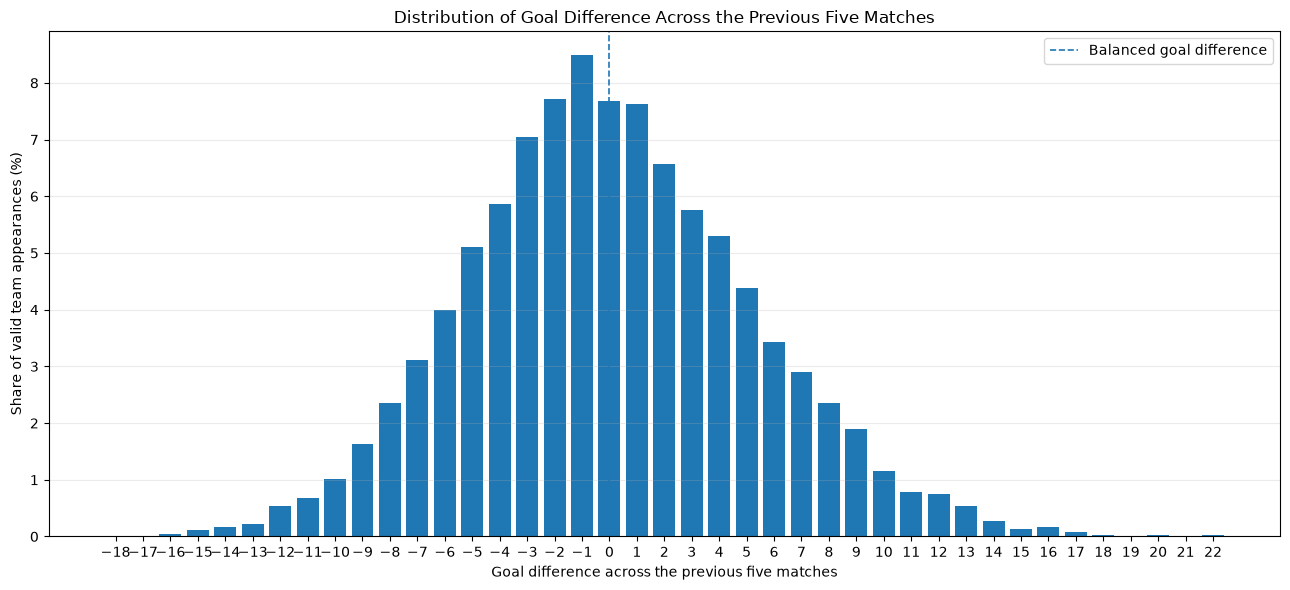

Valid observations: 6,600
Mean: 0.01
Median: 0.00
Standard deviation: 5.23
Skewness: 0.225


,Count,Percentage
RollingGoalDifference5,,
-18,1,0.02
-17,0,0.00
-16,3,0.05
-15,7,0.11
-14,11,0.17
-13,15,0.23
-12,36,0.55
-11,45,0.68
-10,67,1.02


In [42]:
# Extract complete rolling goal-difference observations
rolling_goal_difference = (
    team_history["RollingGoalDifference5"]
    .dropna()
)

# Validate that the feature is integer-valued
assert np.allclose(
    rolling_goal_difference,
    rolling_goal_difference.round(),
)

rolling_goal_difference = rolling_goal_difference.astype(int)

# Recheck the defining identity
complete_form_rows = team_history[
    [
        "RollingGoalsFor5",
        "RollingGoalsAgainst5",
        "RollingGoalDifference5",
    ]
].dropna()

assert np.allclose(
    complete_form_rows["RollingGoalDifference5"],
    (
        complete_form_rows["RollingGoalsFor5"]
        - complete_form_rows["RollingGoalsAgainst5"]
    ),
)

# Construct a complete integer range
minimum_goal_difference = int(
    rolling_goal_difference.min()
)

maximum_goal_difference = int(
    rolling_goal_difference.max()
)

goal_difference_values = np.arange(
    minimum_goal_difference,
    maximum_goal_difference + 1,
)

goal_difference_frequency = (
    rolling_goal_difference
    .value_counts()
    .reindex(
        goal_difference_values,
        fill_value=0,
    )
    .sort_index()
)

goal_difference_percentage = (
    100
    * goal_difference_frequency
    / goal_difference_frequency.sum()
)

rolling_goal_difference_distribution = pd.DataFrame(
    {
        "Count": goal_difference_frequency,
        "Percentage": goal_difference_percentage,
    }
)

# Validate the frequency table
assert (
    goal_difference_frequency.sum()
    == len(rolling_goal_difference)
)

# Plot the whole-dataset distribution
plt.figure(figsize=(13, 6))

plt.bar(
    rolling_goal_difference_distribution.index,
    rolling_goal_difference_distribution["Percentage"],
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1.2,
    label="Balanced goal difference",
)

plt.title(
    "Distribution of Goal Difference "
    "Across the Previous Five Matches"
)
plt.xlabel(
    "Goal difference across the previous five matches"
)
plt.ylabel(
    "Share of valid team appearances (%)"
)

plt.xticks(goal_difference_values)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Valid observations: "
    f"{len(rolling_goal_difference):,}"
)

print(
    f"Mean: "
    f"{rolling_goal_difference.mean():.2f}"
)

print(
    f"Median: "
    f"{rolling_goal_difference.median():.2f}"
)

print(
    f"Standard deviation: "
    f"{rolling_goal_difference.std():.2f}"
)

print(
    f"Skewness: "
    f"{rolling_goal_difference.skew():.3f}"
)

rolling_goal_difference_distribution.round(
    {"Percentage": 2}
)

#### Interpretation

The distribution of `RollingGoalDifference5` summarises the balance between recent attacking and defensive performance.

Most observations are concentrated around moderate values near zero, while highly positive and highly negative five-match goal differences occur less frequently. This indicates that extreme periods of dominance or defensive weakness are relatively unusual.

Positive values represent teams that scored more goals than they conceded during their previous five fixtures. Negative values represent teams that conceded more than they scored.

The feature contains information not fully represented by rolling points. Teams can earn similar points totals while producing different goal differences, particularly when comparing narrow victories with dominant victories or narrow defeats with heavy losses.

The distribution also confirms that the feature contains both positive and negative integer values and remains mathematically consistent with the difference between rolling goals scored and rolling goals conceded.

#### 6.9.5 Distribution of five-match rolling win rate

The five-match rolling win rate measures the proportion of a team's previous five fixtures that resulted in victory.

Define the win indicator as

$$
W_{i,t-j}
=
\begin{cases}
1, & \text{if team } i \text{ won match } t-j,\\
0, & \text{otherwise}.
\end{cases}
$$

For team $i$ before fixture $t$, the feature is

$$
RWR5_{i,t}
=
\frac{1}{5}
\sum_{j=1}^{5}W_{i,t-j}.
$$

Because the rolling window contains exactly five fixtures, the only possible values are

$$
0,\ 0.2,\ 0.4,\ 0.6,\ 0.8,\ 1.0.
$$

These values correspond to winning zero, one, two, three, four or all five of the preceding fixtures.

A frequency bar chart is therefore more appropriate than a continuous histogram.

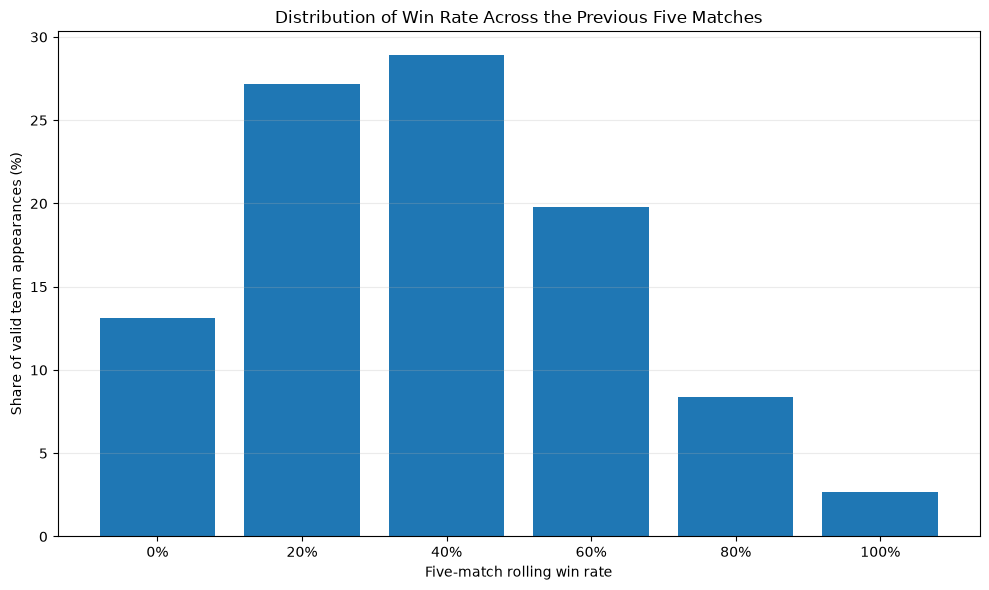

Valid observations: 6,600
Mean rolling win rate: 0.382
Mean wins in previous five matches: 1.91
Median rolling win rate: 0.4
Most frequent rolling win rate: 0.4


,WinsInPreviousFive,WinRate,Count,Percentage
0,0,0.0,865,13.11
1,1,0.2,1795,27.20
2,2,0.4,1907,28.89
3,3,0.6,1305,19.77
4,4,0.8,551,8.35
5,5,1.0,177,2.68


In [43]:
# Extract complete five-match rolling win-rate observations
rolling_win_rate = (
    team_history["RollingWinRate5"]
    .dropna()
    .round(10)
)

# Define every theoretically possible value
possible_win_rates = np.array(
    [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

# Validate the feature range
assert rolling_win_rate.between(0, 1).all()

# Validate that every observation is a multiple of 0.2
assert np.isclose(
    rolling_win_rate * 5,
    np.round(rolling_win_rate * 5),
).all()

# Validate that no unexpected values are present
assert rolling_win_rate.isin(possible_win_rates).all()

# Count each possible win-rate value
win_rate_frequency = (
    rolling_win_rate
    .value_counts()
    .reindex(possible_win_rates, fill_value=0)
    .sort_index()
)

# Convert frequencies into percentages
win_rate_percentage = (
    100
    * win_rate_frequency
    / win_rate_frequency.sum()
)

rolling_win_rate_distribution = pd.DataFrame(
    {
        "WinsInPreviousFive": (
            possible_win_rates * 5
        ).astype(int),
        "WinRate": possible_win_rates,
        "Count": win_rate_frequency.values,
        "Percentage": win_rate_percentage.values,
    }
)

# Validate the frequency table
assert (
    rolling_win_rate_distribution["Count"].sum()
    == len(rolling_win_rate)
)

assert np.isclose(
    rolling_win_rate_distribution["Percentage"].sum(),
    100,
)

# Create readable percentage labels
win_rate_labels = [
    f"{int(rate * 100)}%"
    for rate in possible_win_rates
]

# Plot the distribution
plt.figure(figsize=(10, 6))

plt.bar(
    win_rate_labels,
    rolling_win_rate_distribution["Percentage"],
)

plt.title(
    "Distribution of Win Rate Across the Previous Five Matches"
)
plt.xlabel(
    "Five-match rolling win rate"
)
plt.ylabel(
    "Share of valid team appearances (%)"
)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Numerical summary
print(
    f"Valid observations: "
    f"{len(rolling_win_rate):,}"
)

print(
    f"Mean rolling win rate: "
    f"{rolling_win_rate.mean():.3f}"
)

print(
    f"Mean wins in previous five matches: "
    f"{5 * rolling_win_rate.mean():.2f}"
)

print(
    f"Median rolling win rate: "
    f"{rolling_win_rate.median():.1f}"
)

print(
    f"Most frequent rolling win rate: "
    f"{rolling_win_rate.mode().iloc[0]:.1f}"
)

rolling_win_rate_distribution.round(
    {
        "WinRate": 1,
        "Percentage": 2,
    }
)

#### Interpretation

The distribution confirms that `RollingWinRate5` takes only the six values permitted by a five-match window.

Most observations are expected to occur at intermediate win rates, representing teams that won between one and three of their previous five fixtures. The extreme values of $0\%$ and $100\%$ represent complete winless or perfect winning sequences and should occur less frequently.

The discrete structure distinguishes rolling win rate from rolling points. Win rate records only whether each fixture was won, whereas rolling points also distinguishes between draws and losses.

For example, two teams may both have a rolling win rate of $40\%$ after winning two of their previous five fixtures. However, the team drawing its remaining three matches would have more rolling points than one losing all three.

Consequently, `RollingWinRate5` and `RollingPoints5` are related but not identical measures of recent form. Their degree of overlap will be examined in the subsequent correlation analysis.

### 6.10 Correlation analysis of recent-form features

The recent-form variables measure related aspects of team performance. A correlation analysis is therefore used to assess the degree of overlap between them.

For features $X$ and $Y$, the Pearson correlation coefficient is

$$
\rho_{X,Y}
=
\frac{
\operatorname{Cov}(X,Y)
}{
\sigma_X\sigma_Y
}.
$$

The coefficient lies between $-1$ and $1$:

- values near $1$ indicate a strong positive linear relationship;
- values near $-1$ indicate a strong negative linear relationship;
- values near $0$ indicate a weak linear relationship.

The analysis includes:

- five-match rolling points;
- five-match goals scored;
- five-match goals conceded;
- five-match goal difference;
- five-match win rate.

Particular attention is required for rolling goal difference because

$$
RGD5_{i,t}
=
RGF5_{i,t}-RGA5_{i,t}.
$$

It is therefore an exact linear combination of the goals-scored and goals-conceded features. Although all three variables remain useful for exploratory analysis, including them simultaneously in a linear model would introduce perfect feature redundancy.

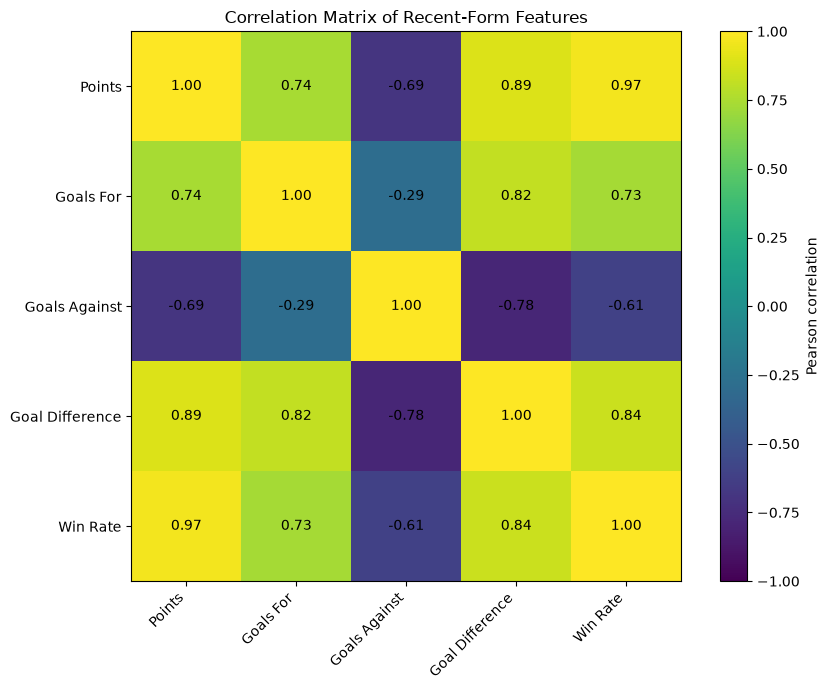

Complete observations: 6,600
Maximum goal-difference identity error: 0.0000000000


,RollingPoints5,RollingGoalsFor5,RollingGoalsAgainst5,RollingGoalDifference5,RollingWinRate5
RollingPoints5,1.000,0.740,-0.694,0.895,0.969
RollingGoalsFor5,0.740,1.000,-0.286,0.819,0.729
RollingGoalsAgainst5,-0.694,-0.286,1.000,-0.784,-0.612
RollingGoalDifference5,0.895,0.819,-0.784,1.000,0.839
RollingWinRate5,0.969,0.729,-0.612,0.839,1.000


In [44]:
# Select the recent-form features
recent_form_features = [
    "RollingPoints5",
    "RollingGoalsFor5",
    "RollingGoalsAgainst5",
    "RollingGoalDifference5",
    "RollingWinRate5",
]

# Retain only complete observations
recent_form_data = (
    team_history[recent_form_features]
    .dropna()
    .copy()
)

# Validate the deterministic goal-difference relationship
goal_difference_residual = (
    recent_form_data["RollingGoalsFor5"]
    - recent_form_data["RollingGoalsAgainst5"]
    - recent_form_data["RollingGoalDifference5"]
)

assert np.allclose(
    goal_difference_residual,
    0,
)

# Calculate the Pearson correlation matrix
recent_form_correlation = (
    recent_form_data
    .corr(method="pearson")
)

# Validate the correlation matrix
assert np.allclose(
    recent_form_correlation,
    recent_form_correlation.T,
)

assert np.allclose(
    np.diag(recent_form_correlation),
    1,
)

assert recent_form_correlation.notna().all().all()

# Create shorter labels for the visualisation
correlation_labels = [
    "Points",
    "Goals For",
    "Goals Against",
    "Goal Difference",
    "Win Rate",
]

# Plot the correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))

correlation_image = ax.imshow(
    recent_form_correlation,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(correlation_labels)),
    labels=correlation_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(correlation_labels)),
    labels=correlation_labels,
)

# Add the numerical correlation to each cell
for row_index in range(len(correlation_labels)):
    for column_index in range(len(correlation_labels)):
        correlation_value = recent_form_correlation.iloc[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"{correlation_value:.2f}",
            ha="center",
            va="center",
        )

ax.set_title(
    "Correlation Matrix of Recent-Form Features"
)

fig.colorbar(
    correlation_image,
    ax=ax,
    label="Pearson correlation",
)

plt.tight_layout()
plt.show()

# Extract each unique feature pair
upper_triangle_mask = np.triu(
    np.ones(
        recent_form_correlation.shape,
        dtype=bool,
    ),
    k=1,
)

pairwise_correlations = (
    recent_form_correlation
    .where(upper_triangle_mask)
    .stack()
    .rename("Correlation")
    .reset_index()
    .rename(
        columns={
            "level_0": "Feature1",
            "level_1": "Feature2",
        }
    )
)

pairwise_correlations["AbsoluteCorrelation"] = (
    pairwise_correlations["Correlation"].abs()
)

pairwise_correlations = (
    pairwise_correlations
    .sort_values(
        "AbsoluteCorrelation",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    f"Complete observations: "
    f"{len(recent_form_data):,}"
)

print(
    "Maximum goal-difference identity error:",
    f"{goal_difference_residual.abs().max():.10f}",
)

recent_form_correlation.round(3)

In [45]:
pairwise_correlations.round(3)

,Feature1,Feature2,Correlation,AbsoluteCorrelation
0,RollingPoints5,RollingWinRate5,0.969,0.969
1,RollingPoints5,RollingGoalDifference5,0.895,0.895
2,RollingGoalDifference5,RollingWinRate5,0.839,0.839
3,RollingGoalsFor5,RollingGoalDifference5,0.819,0.819
4,RollingGoalsAgainst5,RollingGoalDifference5,-0.784,0.784
5,RollingPoints5,RollingGoalsFor5,0.740,0.740
6,RollingGoalsFor5,RollingWinRate5,0.729,0.729
7,RollingPoints5,RollingGoalsAgainst5,-0.694,0.694
8,RollingGoalsAgainst5,RollingWinRate5,-0.612,0.612
9,RollingGoalsFor5,RollingGoalsAgainst5,-0.286,0.286


#### Interpretation

The correlation matrix confirms that the recent-form variables capture related but not entirely identical aspects of performance.

`RollingPoints5` and `RollingWinRate5` are expected to display a strong positive relationship because victories increase both variables. The relationship is not perfect because rolling points distinguish draws from losses, whereas rolling win rate assigns both outcomes a value of zero.

Rolling goals scored should be positively associated with rolling goal difference, while rolling goals conceded should be negatively associated with it. Strong recent scoring records generally improve goal difference, whereas heavy conceding records reduce it.

The relationship between rolling goals scored, rolling goals conceded and rolling goal difference requires particular attention. Since

$$
RollingGoalDifference5
=
RollingGoalsFor5
-
RollingGoalsAgainst5,
$$

the three variables are exactly linearly dependent. They may all be retained during exploratory analysis, but they should not all be included unmodified in the same linear or logistic model.

The correlation analysis is diagnostic rather than a final feature-selection rule. Alternative feature combinations will be compared using chronological out-of-sample validation to determine which representation produces the strongest and most stable predictions.

## 6.11 Chapter summary

This chapter developed point-in-time measures of recent Premier League form using each team's five fixtures immediately preceding the fixture being predicted.

For team $i$ before fixture $t$, the principal recent-form features are:

$$
RP5_{i,t}
=
\sum_{j=1}^{5}P_{i,t-j},
$$

$$
RGF5_{i,t}
=
\sum_{j=1}^{5}GF_{i,t-j},
$$

$$
RGA5_{i,t}
=
\sum_{j=1}^{5}GA_{i,t-j},
$$

$$
RGD5_{i,t}
=
RGF5_{i,t}-RGA5_{i,t},
$$

and

$$
RWR5_{i,t}
=
\frac{1}{5}
\sum_{j=1}^{5}W_{i,t-j}.
$$

The calculations were performed separately for every team-season. A one-match shift was applied before each rolling operation so that the current fixture could not influence its own predictor values. This prevents target leakage and ensures that every feature represents information available before kickoff.

The first five fixtures of each team-season contain missing values because a complete five-match history is not yet available. These missing values are structurally valid and were retained rather than replaced with information from future fixtures or previous seasons.

The team-level features were subsequently merged into the match-level dataset as separate home and away variables. Merge validation confirmed that all fixtures were preserved and that the missing values reconciled with the incomplete rolling windows in the team-level history.

The chapter also examined the statistical behaviour of the engineered features through:

- selected-team rolling-points trajectories;
- whole-dataset rolling-points frequencies;
- rolling goals-scored and goals-conceded distributions;
- the distribution of rolling goal difference;
- the discrete distribution of rolling win rate;
- a Pearson correlation matrix.

The analysis highlighted an exact linear dependency:

$$
RollingGoalDifference5
=
RollingGoalsFor5-RollingGoalsAgainst5.
$$

Therefore, all three variables may be retained for exploratory analysis, but they should not be included simultaneously without adjustment in an unregularised linear or logistic model.

The completed dataset now contains leakage-free measures of recent results, attacking output, defensive vulnerability, goal difference and win frequency for both teams in every eligible fixture. Their predictive contribution will ultimately be assessed using chronological out-of-sample model evaluation.

In [46]:
# Final validation of the Chapter 6 recent-form pipeline

expected_match_count = 3800

recent_form_match_columns = [
    "HomeRollingPoints5",
    "AwayRollingPoints5",
    "HomeRollingGoalsFor5",
    "AwayRollingGoalsFor5",
    "HomeRollingGoalsAgainst5",
    "AwayRollingGoalsAgainst5",
    "HomeRollingGoalDifference5",
    "AwayRollingGoalDifference5",
    "HomeRollingWinRate5",
    "AwayRollingWinRate5",
]


# --------------------------------------------------
# 1. Dataset structure and chronology
# --------------------------------------------------

assert len(matches) == expected_match_count
assert matches["Date"].notna().all()

season_match_counts = matches.groupby("Season").size()

assert season_match_counts.eq(380).all()

assert matches["Date"].is_monotonic_increasing


# --------------------------------------------------
# 2. Required feature columns
# --------------------------------------------------

missing_feature_columns = [
    column
    for column in recent_form_match_columns
    if column not in matches.columns
]

assert not missing_feature_columns, (
    f"Missing recent-form columns: {missing_feature_columns}"
)


# --------------------------------------------------
# 3. Feature ranges
# --------------------------------------------------

for column in [
    "HomeRollingPoints5",
    "AwayRollingPoints5",
]:
    assert matches[column].dropna().between(0, 15).all()


for column in [
    "HomeRollingGoalsFor5",
    "AwayRollingGoalsFor5",
    "HomeRollingGoalsAgainst5",
    "AwayRollingGoalsAgainst5",
]:
    assert matches[column].dropna().ge(0).all()


for column in [
    "HomeRollingWinRate5",
    "AwayRollingWinRate5",
]:
    complete_values = matches[column].dropna()

    assert complete_values.between(0, 1).all()

    assert np.isclose(
        complete_values * 5,
        np.round(complete_values * 5),
    ).all()


# --------------------------------------------------
# 4. Goal-difference identities
# --------------------------------------------------

home_complete = matches[
    [
        "HomeRollingGoalsFor5",
        "HomeRollingGoalsAgainst5",
        "HomeRollingGoalDifference5",
    ]
].notna().all(axis=1)

away_complete = matches[
    [
        "AwayRollingGoalsFor5",
        "AwayRollingGoalsAgainst5",
        "AwayRollingGoalDifference5",
    ]
].notna().all(axis=1)

assert np.allclose(
    matches.loc[
        home_complete,
        "HomeRollingGoalDifference5",
    ],
    (
        matches.loc[
            home_complete,
            "HomeRollingGoalsFor5",
        ]
        - matches.loc[
            home_complete,
            "HomeRollingGoalsAgainst5",
        ]
    ),
)

assert np.allclose(
    matches.loc[
        away_complete,
        "AwayRollingGoalDifference5",
    ],
    (
        matches.loc[
            away_complete,
            "AwayRollingGoalsFor5",
        ]
        - matches.loc[
            away_complete,
            "AwayRollingGoalsAgainst5",
        ]
    ),
)


# --------------------------------------------------
# 5. Missing-value reconciliation
# --------------------------------------------------

team_level_features = [
    "RollingPoints5",
    "RollingGoalsFor5",
    "RollingGoalsAgainst5",
    "RollingGoalDifference5",
    "RollingWinRate5",
]

home_away_feature_pairs = [
    (
        "RollingPoints5",
        "HomeRollingPoints5",
        "AwayRollingPoints5",
    ),
    (
        "RollingGoalsFor5",
        "HomeRollingGoalsFor5",
        "AwayRollingGoalsFor5",
    ),
    (
        "RollingGoalsAgainst5",
        "HomeRollingGoalsAgainst5",
        "AwayRollingGoalsAgainst5",
    ),
    (
        "RollingGoalDifference5",
        "HomeRollingGoalDifference5",
        "AwayRollingGoalDifference5",
    ),
    (
        "RollingWinRate5",
        "HomeRollingWinRate5",
        "AwayRollingWinRate5",
    ),
]

for team_column, home_column, away_column in home_away_feature_pairs:
    expected_missing = team_history[team_column].isna().sum()

    observed_missing = (
        matches[home_column].isna().sum()
        + matches[away_column].isna().sum()
    )

    assert observed_missing == expected_missing


# --------------------------------------------------
# 6. Final audit summary
# --------------------------------------------------

final_validation_summary = pd.DataFrame(
    {
        "Check": [
            "Match rows",
            "Seasons",
            "Missing dates",
            "Recent-form columns",
            "Complete team-level form rows",
        ],
        "Value": [
            len(matches),
            matches["Season"].nunique(),
            matches["Date"].isna().sum(),
            len(recent_form_match_columns),
            team_history[team_level_features]
            .dropna()
            .shape[0],
        ],
    }
)

print("Chapter 6 validation passed successfully.")

final_validation_summary

Chapter 6 validation passed successfully.


,Check,Value
0,Match rows,3800
1,Seasons,10
2,Missing dates,0
3,Recent-form columns,10
4,Complete team-level form rows,6600


## 7. Venue-specific performance

General recent form may conceal differences between a team's home and away performance.

A team can perform strongly at its own stadium while producing considerably weaker results away from home. Venue-specific features are therefore constructed using only the fixtures previously played at the same venue as the fixture being predicted.

For team $i$, season $s$ and venue $v$, define the venue-specific match sequence as

$$
\left\{
M_{i,s,v,1},
M_{i,s,v,2},
\ldots,
M_{i,s,v,19}
\right\},
$$

where

$$
v\in\{\text{Home},\text{Away}\}.
$$

A home-team venue feature will use only the team's previous home fixtures. An away-team venue feature will use only the team's previous away fixtures.

The calculations are performed separately for every team, season and venue. This prevents home and away performances from being mixed and ensures that venue-specific histories reset at each season boundary.

### 7.1 Constructing venue-specific team histories

The existing team-level history already records each fixture from the perspective of both participating teams. A venue-specific history is therefore created by ordering observations within each combination of team, season and venue.

A venue-specific match number is also assigned. This records how many fixtures the team has played at that venue during the current season and will later help validate the rolling-window calculations.

In [47]:
# Create a dedicated venue-specific team history
venue_history = (
    team_history[
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            "Venue",
            "GoalsFor",
            "GoalsAgainst",
            "Points",
            "Win",
        ]
    ]
    .copy()
)

# Order observations chronologically within each team-season-venue group
venue_history = (
    venue_history
    .sort_values(
        [
            "Team",
            "Season",
            "Venue",
            "Date",
            "Opponent",
        ]
    )
    .reset_index(drop=True)
)

# Define the venue-specific groups
venue_groups = venue_history.groupby(
    [
        "Team",
        "Season",
        "Venue",
    ],
    sort=False,
)

# Number fixtures separately within home and away histories
venue_history["VenueMatchNumber"] = (
    venue_groups
    .cumcount()
    + 1
)

# Count the number of home and away fixtures per team-season
venue_fixture_counts = (
    venue_history
    .groupby(
        [
            "Team",
            "Season",
            "Venue",
        ]
    )
    .size()
    .rename("FixtureCount")
    .reset_index()
)

# Validate the venue labels
assert set(venue_history["Venue"].unique()) == {
    "Home",
    "Away",
}

# Each team should play 19 home and 19 away fixtures per season
assert venue_fixture_counts["FixtureCount"].eq(19).all()

# Venue match numbers should run from 1 to 19
venue_number_ranges = (
    venue_history
    .groupby(
        [
            "Team",
            "Season",
            "Venue",
        ]
    )["VenueMatchNumber"]
    .agg(
        FirstVenueMatch="min",
        LastVenueMatch="max",
    )
)

assert venue_number_ranges["FirstVenueMatch"].eq(1).all()
assert venue_number_ranges["LastVenueMatch"].eq(19).all()

# Confirm chronological ordering inside every venue-specific history
venue_ordering_check = (
    venue_history
    .groupby(
        [
            "Team",
            "Season",
            "Venue",
        ]
    )["Date"]
    .apply(lambda dates: dates.is_monotonic_increasing)
)

assert venue_ordering_check.all()

print("Venue-specific team histories constructed successfully.")
print(
    f"Venue-specific team appearances: "
    f"{len(venue_history):,}"
)
print(
    f"Team-season-venue groups: "
    f"{len(venue_fixture_counts):,}"
)

venue_history.head(12)

Venue-specific team histories constructed successfully.
Venue-specific team appearances: 7,600
Team-season-venue groups: 400


,Season,Date,Team,Opponent,Venue,GoalsFor,GoalsAgainst,Points,Win,VenueMatchNumber
0,2015-16,2015-08-16,Arsenal,Crystal Palace,Away,2,1,3,1,1
1,2015-16,2015-08-29,Arsenal,Newcastle,Away,1,0,3,1,2
2,2015-16,2015-09-19,Arsenal,Chelsea,Away,0,2,0,0,3
3,2015-16,2015-09-26,Arsenal,Leicester,Away,5,2,3,1,4
4,2015-16,2015-10-17,Arsenal,Watford,Away,3,0,3,1,5
5,2015-16,2015-10-31,Arsenal,Swansea,Away,3,0,3,1,6
6,2015-16,2015-11-21,Arsenal,West Brom,Away,1,2,0,0,7
7,2015-16,2015-11-29,Arsenal,Norwich,Away,1,1,1,0,8
8,2015-16,2015-12-13,Arsenal,Aston Villa,Away,2,0,3,1,9
9,2015-16,2015-12-26,Arsenal,Southampton,Away,0,4,0,0,10


### 7.2 Five-match venue-specific rolling points

The first venue-specific form feature measures the points earned across a team's previous five fixtures at the same venue.

For team $i$, season $s$, venue $v$ and venue-specific fixture $t$, define

$$
VRP5_{i,s,v,t}
=
\sum_{j=1}^{5}
P_{i,s,v,t-j}.
$$

The points sequence is shifted by one observation before the rolling calculation. Consequently, the current fixture cannot contribute to its own predictor value.

The calculation is performed separately for every combination of team, season and venue:

$$
(i,s,v).
$$

This ensures that home-form values use only previous home fixtures, away-form values use only previous away fixtures, and the rolling history resets at each season boundary.

The theoretical range is

$$
0\leq VRP5_{i,s,v,t}\leq15.
$$

A complete value is unavailable for the first five appearances at each venue because fewer than five previous same-venue fixtures exist.

In [48]:
# Calculate points from the previous five fixtures at the same venue
venue_history["VenueRollingPoints5"] = (
    venue_history
    .groupby(
        [
            "Team",
            "Season",
            "Venue",
        ],
        sort=False,
    )["Points"]
    .transform(
        lambda points: (
            points
            .shift(1)
            .rolling(
                window=5,
                min_periods=5,
            )
            .sum()
        )
    )
)


# --------------------------------------------------
# 1. Validate the expected missing-value structure
# --------------------------------------------------

first_five_venue_matches = (
    venue_history["VenueMatchNumber"] <= 5
)

later_venue_matches = (
    venue_history["VenueMatchNumber"] > 5
)

assert venue_history.loc[
    first_five_venue_matches,
    "VenueRollingPoints5",
].isna().all()

assert venue_history.loc[
    later_venue_matches,
    "VenueRollingPoints5",
].notna().all()


# --------------------------------------------------
# 2. Validate the theoretical range
# --------------------------------------------------

complete_venue_points = (
    venue_history["VenueRollingPoints5"]
    .dropna()
)

assert complete_venue_points.between(0, 15).all()

assert np.allclose(
    complete_venue_points,
    complete_venue_points.round(),
)


# --------------------------------------------------
# 3. Validate the number of missing observations
# --------------------------------------------------

number_of_venue_groups = (
    venue_history[
        [
            "Team",
            "Season",
            "Venue",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_missing_values = (
    number_of_venue_groups * 5
)

observed_missing_values = (
    venue_history["VenueRollingPoints5"]
    .isna()
    .sum()
)

assert observed_missing_values == expected_missing_values


# --------------------------------------------------
# 4. Manually reproduce one sixth venue fixture
# --------------------------------------------------

audit_group_key = (
    venue_history[
        [
            "Team",
            "Season",
            "Venue",
        ]
    ]
    .drop_duplicates()
    .iloc[0]
)

audit_team = audit_group_key["Team"]
audit_season = audit_group_key["Season"]
audit_venue = audit_group_key["Venue"]

audit_group = (
    venue_history.loc[
        (venue_history["Team"] == audit_team)
        & (venue_history["Season"] == audit_season)
        & (venue_history["Venue"] == audit_venue)
    ]
    .sort_values("VenueMatchNumber")
    .reset_index(drop=True)
)

manual_previous_five_points = (
    audit_group.loc[
        0:4,
        "Points",
    ]
    .sum()
)

stored_sixth_match_value = (
    audit_group.loc[
        5,
        "VenueRollingPoints5",
    ]
)

assert np.isclose(
    manual_previous_five_points,
    stored_sixth_match_value,
)


# --------------------------------------------------
# 5. Display the audit
# --------------------------------------------------

print("Venue-specific rolling points calculated successfully.")

print(
    f"Venue groups: "
    f"{number_of_venue_groups:,}"
)

print(
    f"Expected missing values: "
    f"{expected_missing_values:,}"
)

print(
    f"Observed missing values: "
    f"{observed_missing_values:,}"
)

print(
    f"Manual audit: {audit_team}, "
    f"{audit_season}, {audit_venue}"
)

print(
    f"Previous five points: "
    f"{manual_previous_five_points}"
)

print(
    f"Stored sixth-fixture value: "
    f"{stored_sixth_match_value}"
)

audit_group[
    [
        "Season",
        "Date",
        "Team",
        "Opponent",
        "Venue",
        "VenueMatchNumber",
        "Points",
        "VenueRollingPoints5",
    ]
].head(8)

Venue-specific rolling points calculated successfully.
Venue groups: 400
Expected missing values: 2,000
Observed missing values: 2,000
Manual audit: Arsenal, 2015-16, Away
Previous five points: 12
Stored sixth-fixture value: 12.0


,Season,Date,Team,Opponent,Venue,VenueMatchNumber,Points,VenueRollingPoints5
0,2015-16,2015-08-16,Arsenal,Crystal Palace,Away,1,3,NaN
1,2015-16,2015-08-29,Arsenal,Newcastle,Away,2,3,NaN
2,2015-16,2015-09-19,Arsenal,Chelsea,Away,3,0,NaN
3,2015-16,2015-09-26,Arsenal,Leicester,Away,4,3,NaN
4,2015-16,2015-10-17,Arsenal,Watford,Away,5,3,NaN
5,2015-16,2015-10-31,Arsenal,Swansea,Away,6,3,12.0
6,2015-16,2015-11-21,Arsenal,West Brom,Away,7,0,12.0
7,2015-16,2015-11-29,Arsenal,Norwich,Away,8,1,9.0


#### Validation results

The venue-specific rolling-points feature was successfully calculated for every team-season-venue history.

The first five appearances in each venue group contain missing values because a complete five-match same-venue history is not yet available. All later appearances contain valid values between $0$ and $15$.

The total number of missing observations equals

$$
400\times5=2{,}000,
$$

which matches the expected five incomplete windows across each of the 400 team-season-venue groups.

A manual reconstruction of the sixth fixture confirmed that its stored value equals the sum of points earned during the preceding five fixtures at the same venue.

The feature is therefore chronologically correct, season-specific and venue-specific. It contains no information from the current fixture, the opposite venue or a previous season.

### 7.3 Venue-specific goals, goal difference and win rate

Venue-specific rolling points summarise recent results at the relevant venue, but do not describe how those results were produced.

Additional variables are therefore constructed to measure recent same-venue attacking output, defensive vulnerability, goal difference and win frequency.

For team $i$, season $s$, venue $v$ and venue-specific fixture $t$:

$$
VRGF5_{i,s,v,t}
=
\sum_{j=1}^{5}GF_{i,s,v,t-j},
$$

$$
VRGA5_{i,s,v,t}
=
\sum_{j=1}^{5}GA_{i,s,v,t-j},
$$

$$
VRGD5_{i,s,v,t}
=
VRGF5_{i,s,v,t}
-
VRGA5_{i,s,v,t},
$$

and

$$
VRWR5_{i,s,v,t}
=
\frac{1}{5}
\sum_{j=1}^{5}W_{i,s,v,t-j}.
$$

Each sequence is shifted by one fixture before applying the rolling calculation. Consequently, the current fixture cannot influence its own predictor values.

The calculations are performed separately for every team, season and venue, ensuring that home and away histories remain distinct and that all rolling windows reset at season boundaries.

In [49]:
# Define the venue-specific groups
venue_groups = venue_history.groupby(
    [
        "Team",
        "Season",
        "Venue",
    ],
    sort=False,
)


# --------------------------------------------------
# 1. Calculate the additional venue-specific features
# --------------------------------------------------

venue_history["VenueRollingGoalsFor5"] = (
    venue_groups["GoalsFor"]
    .transform(
        lambda goals: (
            goals
            .shift(1)
            .rolling(
                window=5,
                min_periods=5,
            )
            .sum()
        )
    )
)

venue_history["VenueRollingGoalsAgainst5"] = (
    venue_groups["GoalsAgainst"]
    .transform(
        lambda goals: (
            goals
            .shift(1)
            .rolling(
                window=5,
                min_periods=5,
            )
            .sum()
        )
    )
)

venue_history["VenueRollingWinRate5"] = (
    venue_groups["Win"]
    .transform(
        lambda wins: (
            wins
            .shift(1)
            .rolling(
                window=5,
                min_periods=5,
            )
            .mean()
        )
    )
)

venue_history["VenueRollingGoalDifference5"] = (
    venue_history["VenueRollingGoalsFor5"]
    - venue_history["VenueRollingGoalsAgainst5"]
)


# --------------------------------------------------
# 2. Validate the missing-value structure
# --------------------------------------------------

additional_venue_features = [
    "VenueRollingGoalsFor5",
    "VenueRollingGoalsAgainst5",
    "VenueRollingGoalDifference5",
    "VenueRollingWinRate5",
]

first_five_venue_matches = (
    venue_history["VenueMatchNumber"] <= 5
)

later_venue_matches = (
    venue_history["VenueMatchNumber"] > 5
)

assert (
    venue_history.loc[
        first_five_venue_matches,
        additional_venue_features,
    ]
    .isna()
    .all()
    .all()
)

assert (
    venue_history.loc[
        later_venue_matches,
        additional_venue_features,
    ]
    .notna()
    .all()
    .all()
)


# --------------------------------------------------
# 3. Validate goals scored and conceded
# --------------------------------------------------

complete_venue_goals_for = (
    venue_history["VenueRollingGoalsFor5"]
    .dropna()
)

complete_venue_goals_against = (
    venue_history["VenueRollingGoalsAgainst5"]
    .dropna()
)

assert complete_venue_goals_for.ge(0).all()
assert complete_venue_goals_against.ge(0).all()

assert np.allclose(
    complete_venue_goals_for,
    complete_venue_goals_for.round(),
)

assert np.allclose(
    complete_venue_goals_against,
    complete_venue_goals_against.round(),
)


# --------------------------------------------------
# 4. Validate rolling win rate
# --------------------------------------------------

complete_venue_win_rate = (
    venue_history["VenueRollingWinRate5"]
    .dropna()
)

assert complete_venue_win_rate.between(0, 1).all()

assert np.isclose(
    complete_venue_win_rate * 5,
    np.round(complete_venue_win_rate * 5),
).all()


# --------------------------------------------------
# 5. Validate the goal-difference identity
# --------------------------------------------------

complete_venue_form = (
    venue_history[
        [
            "VenueRollingGoalsFor5",
            "VenueRollingGoalsAgainst5",
            "VenueRollingGoalDifference5",
        ]
    ]
    .dropna()
)

assert np.allclose(
    complete_venue_form["VenueRollingGoalDifference5"],
    (
        complete_venue_form["VenueRollingGoalsFor5"]
        - complete_venue_form["VenueRollingGoalsAgainst5"]
    ),
)


# --------------------------------------------------
# 6. Validate the number of missing values
# --------------------------------------------------

number_of_venue_groups = (
    venue_history[
        [
            "Team",
            "Season",
            "Venue",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_missing_per_feature = (
    number_of_venue_groups * 5
)

for column in additional_venue_features:
    observed_missing = (
        venue_history[column]
        .isna()
        .sum()
    )

    assert observed_missing == expected_missing_per_feature


# --------------------------------------------------
# 7. Manually reproduce the sixth fixture
# --------------------------------------------------

audit_key = (
    venue_history[
        [
            "Team",
            "Season",
            "Venue",
        ]
    ]
    .drop_duplicates()
    .iloc[0]
)

audit_team = audit_key["Team"]
audit_season = audit_key["Season"]
audit_venue = audit_key["Venue"]

audit_group = (
    venue_history.loc[
        (venue_history["Team"] == audit_team)
        & (venue_history["Season"] == audit_season)
        & (venue_history["Venue"] == audit_venue)
    ]
    .sort_values("VenueMatchNumber")
    .reset_index(drop=True)
)

previous_five = audit_group.iloc[0:5]

manual_goals_for = previous_five["GoalsFor"].sum()
manual_goals_against = previous_five["GoalsAgainst"].sum()
manual_goal_difference = (
    manual_goals_for - manual_goals_against
)
manual_win_rate = previous_five["Win"].mean()

stored_sixth_fixture = audit_group.iloc[5]

assert np.isclose(
    stored_sixth_fixture["VenueRollingGoalsFor5"],
    manual_goals_for,
)

assert np.isclose(
    stored_sixth_fixture["VenueRollingGoalsAgainst5"],
    manual_goals_against,
)

assert np.isclose(
    stored_sixth_fixture["VenueRollingGoalDifference5"],
    manual_goal_difference,
)

assert np.isclose(
    stored_sixth_fixture["VenueRollingWinRate5"],
    manual_win_rate,
)


# --------------------------------------------------
# 8. Display the validation results
# --------------------------------------------------

manual_audit = pd.DataFrame(
    {
        "Feature": [
            "Goals For",
            "Goals Against",
            "Goal Difference",
            "Win Rate",
        ],
        "ManualValue": [
            manual_goals_for,
            manual_goals_against,
            manual_goal_difference,
            manual_win_rate,
        ],
        "StoredSixthFixtureValue": [
            stored_sixth_fixture[
                "VenueRollingGoalsFor5"
            ],
            stored_sixth_fixture[
                "VenueRollingGoalsAgainst5"
            ],
            stored_sixth_fixture[
                "VenueRollingGoalDifference5"
            ],
            stored_sixth_fixture[
                "VenueRollingWinRate5"
            ],
        ],
    }
)

print(
    "Additional venue-specific rolling features "
    "calculated successfully."
)

print(
    f"Venue groups: "
    f"{number_of_venue_groups:,}"
)

print(
    f"Expected missing values per feature: "
    f"{expected_missing_per_feature:,}"
)

print(
    f"Audit group: "
    f"{audit_team}, {audit_season}, {audit_venue}"
)

manual_audit

Additional venue-specific rolling features calculated successfully.
Venue groups: 400
Expected missing values per feature: 2,000
Audit group: Arsenal, 2015-16, Away


,Feature,ManualValue,StoredSixthFixtureValue
0,Goals For,11.0,11.0
1,Goals Against,5.0,5.0
2,Goal Difference,6.0,6.0
3,Win Rate,0.8,0.8


#### Validation results

The additional venue-specific rolling features were successfully calculated for all team-season-venue histories.

The first five appearances in each venue group contain missing values because fewer than five previous same-venue fixtures are available. All later observations contain complete values.

The validation confirmed that:

- venue-specific goals scored and conceded are non-negative integers;
- venue-specific win rates lie between $0$ and $1$;
- every win-rate value is a multiple of $0.2$;
- venue-specific goal difference satisfies

$$
VenueRollingGoalDifference5
=
VenueRollingGoalsFor5
-
VenueRollingGoalsAgainst5;
$$

- each feature contains exactly $2{,}000$ structurally missing observations.

A manual reconstruction of the sixth fixture reproduced all four stored feature values using only the previous five fixtures played at the same venue.

The features are therefore point-in-time correct and contain no information from the current fixture, the opposite venue or a previous season.

### 7.4 Merging venue-specific features into the match-level dataset

The venue-specific features are currently stored in a team-level dataset containing separate home and away appearances.

To make these variables available for modelling, the home and away observations are separated and merged into the match-level dataset.

Each fixture receives ten new predictors:

- home and away venue-specific rolling points;
- home and away venue-specific goals scored;
- home and away venue-specific goals conceded;
- home and away venue-specific goal difference;
- home and away venue-specific win rate.

For the home team, each value is calculated using only its previous five home fixtures. For the away team, each value is calculated using only its previous five away fixtures.

The merge uses season, date, home team and away team as fixture identifiers. One-to-one merge validation and merge indicators are used to confirm that every fixture is matched exactly once.

Structurally missing early-season rolling values are retained. These represent fixtures for which the relevant team has not yet played five previous matches at the same venue.

In [50]:
# Venue-specific features to transfer into the match-level dataset
venue_feature_columns = [
    "VenueRollingPoints5",
    "VenueRollingGoalsFor5",
    "VenueRollingGoalsAgainst5",
    "VenueRollingGoalDifference5",
    "VenueRollingWinRate5",
]

merge_keys = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
]


# --------------------------------------------------
# 1. Construct the home-team lookup
# --------------------------------------------------

home_venue_lookup = (
    venue_history.loc[
        venue_history["Venue"] == "Home",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            *venue_feature_columns,
        ],
    ]
    .rename(
        columns={
            "Team": "HomeTeam",
            "Opponent": "AwayTeam",
            "VenueRollingPoints5":
                "HomeVenueRollingPoints5",
            "VenueRollingGoalsFor5":
                "HomeVenueRollingGoalsFor5",
            "VenueRollingGoalsAgainst5":
                "HomeVenueRollingGoalsAgainst5",
            "VenueRollingGoalDifference5":
                "HomeVenueRollingGoalDifference5",
            "VenueRollingWinRate5":
                "HomeVenueRollingWinRate5",
        }
    )
)


# --------------------------------------------------
# 2. Construct the away-team lookup
# --------------------------------------------------

away_venue_lookup = (
    venue_history.loc[
        venue_history["Venue"] == "Away",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            *venue_feature_columns,
        ],
    ]
    .rename(
        columns={
            "Team": "AwayTeam",
            "Opponent": "HomeTeam",
            "VenueRollingPoints5":
                "AwayVenueRollingPoints5",
            "VenueRollingGoalsFor5":
                "AwayVenueRollingGoalsFor5",
            "VenueRollingGoalsAgainst5":
                "AwayVenueRollingGoalsAgainst5",
            "VenueRollingGoalDifference5":
                "AwayVenueRollingGoalDifference5",
            "VenueRollingWinRate5":
                "AwayVenueRollingWinRate5",
        }
    )
)


# Each lookup should contain exactly one row per fixture
assert len(home_venue_lookup) == len(matches)
assert len(away_venue_lookup) == len(matches)

assert not home_venue_lookup.duplicated(
    subset=merge_keys
).any()

assert not away_venue_lookup.duplicated(
    subset=merge_keys
).any()


# --------------------------------------------------
# 3. Make the cell safe to rerun
# --------------------------------------------------

new_venue_match_columns = [
    "HomeVenueRollingPoints5",
    "AwayVenueRollingPoints5",
    "HomeVenueRollingGoalsFor5",
    "AwayVenueRollingGoalsFor5",
    "HomeVenueRollingGoalsAgainst5",
    "AwayVenueRollingGoalsAgainst5",
    "HomeVenueRollingGoalDifference5",
    "AwayVenueRollingGoalDifference5",
    "HomeVenueRollingWinRate5",
    "AwayVenueRollingWinRate5",
]

columns_to_remove = [
    column
    for column in [
        *new_venue_match_columns,
        "_home_venue_merge",
        "_away_venue_merge",
    ]
    if column in matches.columns
]

matches = matches.drop(
    columns=columns_to_remove
)

original_match_count = len(matches)


# --------------------------------------------------
# 4. Merge the home-team venue features
# --------------------------------------------------

matches = matches.merge(
    home_venue_lookup,
    on=merge_keys,
    how="left",
    validate="one_to_one",
    indicator="_home_venue_merge",
)

assert matches["_home_venue_merge"].eq("both").all()


# --------------------------------------------------
# 5. Merge the away-team venue features
# --------------------------------------------------

matches = matches.merge(
    away_venue_lookup,
    on=merge_keys,
    how="left",
    validate="one_to_one",
    indicator="_away_venue_merge",
)

assert matches["_away_venue_merge"].eq("both").all()

matches = matches.drop(
    columns=[
        "_home_venue_merge",
        "_away_venue_merge",
    ]
)


# --------------------------------------------------
# 6. Confirm fixture preservation
# --------------------------------------------------

assert len(matches) == original_match_count


# --------------------------------------------------
# 7. Validate feature ranges
# --------------------------------------------------

for column in [
    "HomeVenueRollingPoints5",
    "AwayVenueRollingPoints5",
]:
    complete_values = matches[column].dropna()

    assert complete_values.between(0, 15).all()

    assert np.allclose(
        complete_values,
        complete_values.round(),
    )


for column in [
    "HomeVenueRollingGoalsFor5",
    "AwayVenueRollingGoalsFor5",
    "HomeVenueRollingGoalsAgainst5",
    "AwayVenueRollingGoalsAgainst5",
]:
    complete_values = matches[column].dropna()

    assert complete_values.ge(0).all()

    assert np.allclose(
        complete_values,
        complete_values.round(),
    )


for column in [
    "HomeVenueRollingWinRate5",
    "AwayVenueRollingWinRate5",
]:
    complete_values = matches[column].dropna()

    assert complete_values.between(0, 1).all()

    assert np.isclose(
        complete_values * 5,
        np.round(complete_values * 5),
    ).all()


# --------------------------------------------------
# 8. Validate the goal-difference identities
# --------------------------------------------------

home_complete = matches[
    [
        "HomeVenueRollingGoalsFor5",
        "HomeVenueRollingGoalsAgainst5",
        "HomeVenueRollingGoalDifference5",
    ]
].notna().all(axis=1)

away_complete = matches[
    [
        "AwayVenueRollingGoalsFor5",
        "AwayVenueRollingGoalsAgainst5",
        "AwayVenueRollingGoalDifference5",
    ]
].notna().all(axis=1)

assert np.allclose(
    matches.loc[
        home_complete,
        "HomeVenueRollingGoalDifference5",
    ],
    (
        matches.loc[
            home_complete,
            "HomeVenueRollingGoalsFor5",
        ]
        - matches.loc[
            home_complete,
            "HomeVenueRollingGoalsAgainst5",
        ]
    ),
)

assert np.allclose(
    matches.loc[
        away_complete,
        "AwayVenueRollingGoalDifference5",
    ],
    (
        matches.loc[
            away_complete,
            "AwayVenueRollingGoalsFor5",
        ]
        - matches.loc[
            away_complete,
            "AwayVenueRollingGoalsAgainst5",
        ]
    ),
)


# --------------------------------------------------
# 9. Reconcile the missing values
# --------------------------------------------------

venue_feature_pairs = [
    (
        "VenueRollingPoints5",
        "HomeVenueRollingPoints5",
        "AwayVenueRollingPoints5",
    ),
    (
        "VenueRollingGoalsFor5",
        "HomeVenueRollingGoalsFor5",
        "AwayVenueRollingGoalsFor5",
    ),
    (
        "VenueRollingGoalsAgainst5",
        "HomeVenueRollingGoalsAgainst5",
        "AwayVenueRollingGoalsAgainst5",
    ),
    (
        "VenueRollingGoalDifference5",
        "HomeVenueRollingGoalDifference5",
        "AwayVenueRollingGoalDifference5",
    ),
    (
        "VenueRollingWinRate5",
        "HomeVenueRollingWinRate5",
        "AwayVenueRollingWinRate5",
    ),
]

missing_value_audit = []

for team_column, home_column, away_column in venue_feature_pairs:
    expected_missing = (
        venue_history[team_column]
        .isna()
        .sum()
    )

    observed_missing = (
        matches[home_column].isna().sum()
        + matches[away_column].isna().sum()
    )

    assert observed_missing == expected_missing

    missing_value_audit.append(
        {
            "Feature": team_column,
            "ExpectedMissing": expected_missing,
            "ObservedMissing": observed_missing,
        }
    )

missing_value_audit = pd.DataFrame(
    missing_value_audit
)


# --------------------------------------------------
# 10. Display the validation results
# --------------------------------------------------

print("Venue-specific features merged successfully.")

print(
    f"Match rows before merge: "
    f"{original_match_count:,}"
)

print(
    f"Match rows after merge: "
    f"{len(matches):,}"
)

print(
    f"New venue-specific columns: "
    f"{len(new_venue_match_columns)}"
)

missing_value_audit

Venue-specific features merged successfully.
Match rows before merge: 3,800
Match rows after merge: 3,800
New venue-specific columns: 10


,Feature,ExpectedMissing,ObservedMissing
0,VenueRollingPoints5,2000,2000
1,VenueRollingGoalsFor5,2000,2000
2,VenueRollingGoalsAgainst5,2000,2000
3,VenueRollingGoalDifference5,2000,2000
4,VenueRollingWinRate5,2000,2000


In [51]:
matches[
    [
        "Season",
        "Date",
        "HomeTeam",
        "AwayTeam",
        "HomeRollingPoints5",
        "AwayRollingPoints5",
        "HomeVenueRollingPoints5",
        "AwayVenueRollingPoints5",
        "HomeVenueRollingGoalsFor5",
        "AwayVenueRollingGoalsFor5",
        "HomeVenueRollingGoalsAgainst5",
        "AwayVenueRollingGoalsAgainst5",
        "HomeVenueRollingGoalDifference5",
        "AwayVenueRollingGoalDifference5",
        "HomeVenueRollingWinRate5",
        "AwayVenueRollingWinRate5",
    ]
].head(15)

,Season,Date,HomeTeam,AwayTeam,HomeRollingPoints5,AwayRollingPoints5,HomeVenueRollingPoints5,AwayVenueRollingPoints5,HomeVenueRollingGoalsFor5,AwayVenueRollingGoalsFor5,HomeVenueRollingGoalsAgainst5,AwayVenueRollingGoalsAgainst5,HomeVenueRollingGoalDifference5,AwayVenueRollingGoalDifference5,HomeVenueRollingWinRate5,AwayVenueRollingWinRate5
0,2015-16,2015-08-08,Bournemouth,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-16,2015-08-08,Chelsea,Swansea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-16,2015-08-08,Everton,Watford,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-16,2015-08-08,Leicester,Sunderland,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-16,2015-08-08,Man United,Tottenham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2015-16,2015-08-08,Norwich,Crystal Palace,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2015-16,2015-08-09,Arsenal,West Ham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2015-16,2015-08-09,Newcastle,Southampton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2015-16,2015-08-09,Stoke,Liverpool,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2015-16,2015-08-10,West Brom,Man City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Merge validation results

The venue-specific features were successfully merged into the match-level dataset.

All $3{,}800$ fixtures were preserved, and the home and away lookup tables matched every fixture exactly once. Merge indicators confirmed complete key coverage independently of the structurally missing rolling values.

The validation also confirmed that:

- venue-specific rolling points remain between $0$ and $15$;
- goals scored and conceded remain non-negative integers;
- venue-specific win rates remain between $0$ and $1$ and are multiples of $0.2$;
- venue-specific goal difference satisfies

$$
VenueRollingGoalDifference5
=
VenueRollingGoalsFor5
-
VenueRollingGoalsAgainst5;
$$

- the match-level missing values reconcile exactly with the incomplete same-venue rolling windows in `venue_history`.

The modelling dataset now contains separate measures of the home team's recent home performance and the away team's recent away performance for every eligible fixture.

### 7.5 Comparing general and venue-specific recent form

The venue-specific features are compared with their general recent-form equivalents to determine whether they provide distinct information.

General recent form uses a team's previous five fixtures at any venue, whereas venue-specific form uses its previous five fixtures played at the same venue as the upcoming match.

For corresponding general and venue-specific features, the difference is

$$
D_{i,t}
=
V_{i,t}-G_{i,t}.
$$

The mean absolute difference is

$$
MAE_{G,V}
=
\frac{1}{N}
\sum_{t=1}^{N}
|V_{i,t}-G_{i,t}|.
$$

A larger mean absolute difference indicates greater match-level disagreement between the two feature definitions.

Pearson correlation measures how closely the variables move together. A high but imperfect correlation would indicate that venue-specific form is related to general form while still containing additional information.

Feature availability is also compared because venue-specific values require five previous matches at the same venue and therefore become available later in each season.

In [59]:
form_feature_pairs = [
    (
        "Points",
        "HomeRollingPoints5",
        "HomeVenueRollingPoints5",
        "AwayRollingPoints5",
        "AwayVenueRollingPoints5",
    ),
    (
        "Goals For",
        "HomeRollingGoalsFor5",
        "HomeVenueRollingGoalsFor5",
        "AwayRollingGoalsFor5",
        "AwayVenueRollingGoalsFor5",
    ),
    (
        "Goals Against",
        "HomeRollingGoalsAgainst5",
        "HomeVenueRollingGoalsAgainst5",
        "AwayRollingGoalsAgainst5",
        "AwayVenueRollingGoalsAgainst5",
    ),
    (
        "Goal Difference",
        "HomeRollingGoalDifference5",
        "HomeVenueRollingGoalDifference5",
        "AwayRollingGoalDifference5",
        "AwayVenueRollingGoalDifference5",
    ),
    (
        "Win Rate",
        "HomeRollingWinRate5",
        "HomeVenueRollingWinRate5",
        "AwayRollingWinRate5",
        "AwayVenueRollingWinRate5",
    ),
]

comparison_rows = []

for (
    feature,
    home_general,
    home_venue,
    away_general,
    away_venue,
) in form_feature_pairs:

    for side, general_column, venue_column in [
        ("Home", home_general, home_venue),
        ("Away", away_general, away_venue),
    ]:
        paired = matches[
            [general_column, venue_column]
        ].dropna()

        difference = (
            paired[venue_column]
            - paired[general_column]
        )

        comparison_rows.append(
            {
                "Side": side,
                "Feature": feature,
                "General availability (%)": (
                    100
                    * matches[general_column].notna().mean()
                ),
                "Venue availability (%)": (
                    100
                    * matches[venue_column].notna().mean()
                ),
                "Correlation": paired[
                    general_column
                ].corr(
                    paired[venue_column]
                ),
                "Mean absolute difference": (
                    difference.abs().mean()
                ),
            }
        )

general_venue_comparison = pd.DataFrame(
    comparison_rows
)

general_venue_comparison.round(
    {
        "General availability (%)": 1,
        "Venue availability (%)": 1,
        "Correlation": 3,
        "Mean absolute difference": 3,
    }
)

,Side,Feature,General availability (%),Venue availability (%),Correlation,Mean absolute difference
0,Home,Points,86.8,73.7,0.650,2.425
1,Away,Points,86.9,73.7,0.645,2.428
2,Home,Goals For,86.8,73.7,0.668,2.268
3,Away,Goals For,86.9,73.7,0.614,2.290
4,Home,Goals Against,86.8,73.7,0.582,2.282
5,Away,Goals Against,86.9,73.7,0.584,2.286
6,Home,Goal Difference,86.8,73.7,0.684,3.539
7,Away,Goal Difference,86.9,73.7,0.658,3.511
8,Home,Win Rate,86.8,73.7,0.634,0.166
9,Away,Win Rate,86.9,73.7,0.616,0.168


#### Interpretation

The comparison shows whether venue-specific form contains information beyond the general recent-form variables.

Positive correlations are expected because both feature sets are derived from recent team performance. However, correlations below $1$ and non-zero mean absolute differences demonstrate that the two definitions are not interchangeable.

Venue-specific form can differ from general form when a team performs substantially better or worse at home than away. For example, a team may have weak results across its previous five matches overall while maintaining a strong record across its previous five home fixtures.

The venue-specific variables have lower availability because teams require five previous matches at the relevant venue before the features can be calculated. This represents a trade-off between greater venue relevance and increased early-season missingness.

The final decision on whether to retain these features will be based on chronological model validation. Models with and without the venue-specific feature group will be compared to determine whether the added information improves out-of-sample probability forecasts.

### 7.6 Final validation of the venue-specific feature pipeline

A final audit is performed before closing the venue-specific feature chapter.

The validation confirms that:

- all fixtures remain present;
- all required home and away venue features exist;
- each match-level value agrees with its original team-level source;
- home features originate only from home histories;
- away features originate only from away histories;
- feature ranges and mathematical identities remain valid;
- all missing values correspond to incomplete five-match same-venue windows.

For the home and away goal-difference features, the defining identities are

$$
HVRGD5_t
=
HVRGF5_t-HVRGA5_t,
$$

and

$$
AVRGD5_t
=
AVRGF5_t-AVRGA5_t.
$$

There are 200 team-season histories for each venue. Since the first five observations in every history lack a complete same-venue window, each home and away feature should contain

$$
200\times5=1{,}000
$$

structurally missing values.

In [60]:
# Final validation of the Chapter 7 venue-specific feature pipeline

expected_match_count = 3800

merge_keys = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
]

venue_match_columns = [
    "HomeVenueRollingPoints5",
    "AwayVenueRollingPoints5",
    "HomeVenueRollingGoalsFor5",
    "AwayVenueRollingGoalsFor5",
    "HomeVenueRollingGoalsAgainst5",
    "AwayVenueRollingGoalsAgainst5",
    "HomeVenueRollingGoalDifference5",
    "AwayVenueRollingGoalDifference5",
    "HomeVenueRollingWinRate5",
    "AwayVenueRollingWinRate5",
]


# --------------------------------------------------
# 1. Validate dataset structure
# --------------------------------------------------

assert len(matches) == expected_match_count
assert matches["Date"].notna().all()
assert matches["Date"].is_monotonic_increasing

season_match_counts = (
    matches
    .groupby("Season")
    .size()
)

assert season_match_counts.eq(380).all()

assert not matches.duplicated(
    subset=merge_keys
).any()


# --------------------------------------------------
# 2. Confirm that every required feature exists
# --------------------------------------------------

missing_columns = [
    column
    for column in venue_match_columns
    if column not in matches.columns
]

assert not missing_columns, (
    f"Missing venue-specific columns: {missing_columns}"
)


# --------------------------------------------------
# 3. Validate feature ranges
# --------------------------------------------------

for column in [
    "HomeVenueRollingPoints5",
    "AwayVenueRollingPoints5",
]:
    values = matches[column].dropna()

    assert values.between(0, 15).all()
    assert np.allclose(values, values.round())


for column in [
    "HomeVenueRollingGoalsFor5",
    "AwayVenueRollingGoalsFor5",
    "HomeVenueRollingGoalsAgainst5",
    "AwayVenueRollingGoalsAgainst5",
]:
    values = matches[column].dropna()

    assert values.ge(0).all()
    assert np.allclose(values, values.round())


for column in [
    "HomeVenueRollingWinRate5",
    "AwayVenueRollingWinRate5",
]:
    values = matches[column].dropna()

    assert values.between(0, 1).all()

    assert np.isclose(
        values * 5,
        np.round(values * 5),
    ).all()


# --------------------------------------------------
# 4. Validate goal-difference identities
# --------------------------------------------------

home_complete = matches[
    [
        "HomeVenueRollingGoalsFor5",
        "HomeVenueRollingGoalsAgainst5",
        "HomeVenueRollingGoalDifference5",
    ]
].notna().all(axis=1)

away_complete = matches[
    [
        "AwayVenueRollingGoalsFor5",
        "AwayVenueRollingGoalsAgainst5",
        "AwayVenueRollingGoalDifference5",
    ]
].notna().all(axis=1)

assert np.allclose(
    matches.loc[
        home_complete,
        "HomeVenueRollingGoalDifference5",
    ],
    (
        matches.loc[
            home_complete,
            "HomeVenueRollingGoalsFor5",
        ]
        - matches.loc[
            home_complete,
            "HomeVenueRollingGoalsAgainst5",
        ]
    ),
)

assert np.allclose(
    matches.loc[
        away_complete,
        "AwayVenueRollingGoalDifference5",
    ],
    (
        matches.loc[
            away_complete,
            "AwayVenueRollingGoalsFor5",
        ]
        - matches.loc[
            away_complete,
            "AwayVenueRollingGoalsAgainst5",
        ]
    ),
)


# --------------------------------------------------
# 5. Reconstruct the original home source values
# --------------------------------------------------

home_source = (
    venue_history.loc[
        venue_history["Venue"] == "Home",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            "VenueRollingPoints5",
            "VenueRollingGoalsFor5",
            "VenueRollingGoalsAgainst5",
            "VenueRollingGoalDifference5",
            "VenueRollingWinRate5",
        ],
    ]
    .rename(
        columns={
            "Team": "HomeTeam",
            "Opponent": "AwayTeam",
            "VenueRollingPoints5":
                "SourceHomeVenueRollingPoints5",
            "VenueRollingGoalsFor5":
                "SourceHomeVenueRollingGoalsFor5",
            "VenueRollingGoalsAgainst5":
                "SourceHomeVenueRollingGoalsAgainst5",
            "VenueRollingGoalDifference5":
                "SourceHomeVenueRollingGoalDifference5",
            "VenueRollingWinRate5":
                "SourceHomeVenueRollingWinRate5",
        }
    )
)


# --------------------------------------------------
# 6. Reconstruct the original away source values
# --------------------------------------------------

away_source = (
    venue_history.loc[
        venue_history["Venue"] == "Away",
        [
            "Season",
            "Date",
            "Team",
            "Opponent",
            "VenueRollingPoints5",
            "VenueRollingGoalsFor5",
            "VenueRollingGoalsAgainst5",
            "VenueRollingGoalDifference5",
            "VenueRollingWinRate5",
        ],
    ]
    .rename(
        columns={
            "Team": "AwayTeam",
            "Opponent": "HomeTeam",
            "VenueRollingPoints5":
                "SourceAwayVenueRollingPoints5",
            "VenueRollingGoalsFor5":
                "SourceAwayVenueRollingGoalsFor5",
            "VenueRollingGoalsAgainst5":
                "SourceAwayVenueRollingGoalsAgainst5",
            "VenueRollingGoalDifference5":
                "SourceAwayVenueRollingGoalDifference5",
            "VenueRollingWinRate5":
                "SourceAwayVenueRollingWinRate5",
        }
    )
)

assert len(home_source) == expected_match_count
assert len(away_source) == expected_match_count

assert not home_source.duplicated(
    subset=merge_keys
).any()

assert not away_source.duplicated(
    subset=merge_keys
).any()


# --------------------------------------------------
# 7. Compare match-level values with their sources
# --------------------------------------------------

source_validation = (
    matches[
        merge_keys
        + venue_match_columns
    ]
    .merge(
        home_source,
        on=merge_keys,
        how="left",
        validate="one_to_one",
    )
    .merge(
        away_source,
        on=merge_keys,
        how="left",
        validate="one_to_one",
    )
)

home_source_pairs = [
    (
        "HomeVenueRollingPoints5",
        "SourceHomeVenueRollingPoints5",
    ),
    (
        "HomeVenueRollingGoalsFor5",
        "SourceHomeVenueRollingGoalsFor5",
    ),
    (
        "HomeVenueRollingGoalsAgainst5",
        "SourceHomeVenueRollingGoalsAgainst5",
    ),
    (
        "HomeVenueRollingGoalDifference5",
        "SourceHomeVenueRollingGoalDifference5",
    ),
    (
        "HomeVenueRollingWinRate5",
        "SourceHomeVenueRollingWinRate5",
    ),
]

away_source_pairs = [
    (
        "AwayVenueRollingPoints5",
        "SourceAwayVenueRollingPoints5",
    ),
    (
        "AwayVenueRollingGoalsFor5",
        "SourceAwayVenueRollingGoalsFor5",
    ),
    (
        "AwayVenueRollingGoalsAgainst5",
        "SourceAwayVenueRollingGoalsAgainst5",
    ),
    (
        "AwayVenueRollingGoalDifference5",
        "SourceAwayVenueRollingGoalDifference5",
    ),
    (
        "AwayVenueRollingWinRate5",
        "SourceAwayVenueRollingWinRate5",
    ),
]

for match_column, source_column in (
    home_source_pairs + away_source_pairs
):
    assert np.allclose(
        source_validation[match_column],
        source_validation[source_column],
        equal_nan=True,
    )


# --------------------------------------------------
# 8. Validate side-specific missing values
# --------------------------------------------------

missing_value_rows = []

venue_feature_mapping = [
    (
        "VenueRollingPoints5",
        "HomeVenueRollingPoints5",
        "AwayVenueRollingPoints5",
    ),
    (
        "VenueRollingGoalsFor5",
        "HomeVenueRollingGoalsFor5",
        "AwayVenueRollingGoalsFor5",
    ),
    (
        "VenueRollingGoalsAgainst5",
        "HomeVenueRollingGoalsAgainst5",
        "AwayVenueRollingGoalsAgainst5",
    ),
    (
        "VenueRollingGoalDifference5",
        "HomeVenueRollingGoalDifference5",
        "AwayVenueRollingGoalDifference5",
    ),
    (
        "VenueRollingWinRate5",
        "HomeVenueRollingWinRate5",
        "AwayVenueRollingWinRate5",
    ),
]

for source_column, home_column, away_column in (
    venue_feature_mapping
):
    expected_home_missing = (
        venue_history.loc[
            venue_history["Venue"] == "Home",
            source_column,
        ]
        .isna()
        .sum()
    )

    expected_away_missing = (
        venue_history.loc[
            venue_history["Venue"] == "Away",
            source_column,
        ]
        .isna()
        .sum()
    )

    observed_home_missing = (
        matches[home_column]
        .isna()
        .sum()
    )

    observed_away_missing = (
        matches[away_column]
        .isna()
        .sum()
    )

    assert expected_home_missing == observed_home_missing
    assert expected_away_missing == observed_away_missing

    assert observed_home_missing == 1000
    assert observed_away_missing == 1000

    missing_value_rows.append(
        {
            "Feature": source_column,
            "HomeMissing": observed_home_missing,
            "AwayMissing": observed_away_missing,
            "TotalMissing": (
                observed_home_missing
                + observed_away_missing
            ),
        }
    )

venue_missing_audit = pd.DataFrame(
    missing_value_rows
)


# --------------------------------------------------
# 9. Produce the final validation summary
# --------------------------------------------------

venue_validation_summary = pd.DataFrame(
    {
        "Check": [
            "Match rows",
            "Seasons",
            "Venue-specific match columns",
            "Home source matches",
            "Away source matches",
            "Missing home values per feature",
            "Missing away values per feature",
        ],
        "Value": [
            len(matches),
            matches["Season"].nunique(),
            len(venue_match_columns),
            len(home_source),
            len(away_source),
            venue_missing_audit["HomeMissing"].iloc[0],
            venue_missing_audit["AwayMissing"].iloc[0],
        ],
    }
)

print(
    "Chapter 7 venue-feature validation "
    "passed successfully."
)

venue_validation_summary

Chapter 7 venue-feature validation passed successfully.


,Check,Value
0,Match rows,3800
1,Seasons,10
2,Venue-specific match columns,10
3,Home source matches,3800
4,Away source matches,3800
5,Missing home values per feature,1000
6,Missing away values per feature,1000


In [61]:
venue_missing_audit

,Feature,HomeMissing,AwayMissing,TotalMissing
0,VenueRollingPoints5,1000,1000,2000
1,VenueRollingGoalsFor5,1000,1000,2000
2,VenueRollingGoalsAgainst5,1000,1000,2000
3,VenueRollingGoalDifference5,1000,1000,2000
4,VenueRollingWinRate5,1000,1000,2000


## 7.7 Chapter summary

This chapter developed venue-specific measures of recent Premier League performance.

The general recent-form variables constructed in Chapter 6 use a team's previous five fixtures regardless of venue. However, teams may perform differently at home and away. Venue-specific features were therefore calculated using only the previous fixtures played at the same venue as the upcoming match.

For team $i$, season $s$, venue $v$ and venue-specific fixture $t$, the principal features are:

$$
VRP5_{i,s,v,t}
=
\sum_{j=1}^{5}P_{i,s,v,t-j},
$$

$$
VRGF5_{i,s,v,t}
=
\sum_{j=1}^{5}GF_{i,s,v,t-j},
$$

$$
VRGA5_{i,s,v,t}
=
\sum_{j=1}^{5}GA_{i,s,v,t-j},
$$

$$
VRGD5_{i,s,v,t}
=
VRGF5_{i,s,v,t}
-
VRGA5_{i,s,v,t},
$$

and

$$
VRWR5_{i,s,v,t}
=
\frac{1}{5}
\sum_{j=1}^{5}W_{i,s,v,t-j}.
$$

The calculations were performed separately for every combination of team, season and venue:

$$
(i,s,v).
$$

This ensures that:

- home-form variables use only previous home fixtures;
- away-form variables use only previous away fixtures;
- venue histories reset at each season boundary;
- the current fixture cannot influence its own predictor values.

A one-fixture shift was applied before every rolling calculation. Consequently, all venue-specific variables represent information that would have been available before kickoff.

Each team plays 19 home fixtures and 19 away fixtures during a complete Premier League season. A complete five-match same-venue history is therefore unavailable for the first five home appearances and first five away appearances of each team-season.

Across the 400 team-season-venue histories, this produces

$$
400\times5=2{,}000
$$

structurally missing observations for each team-level venue feature.

At the match level, this corresponds to:

$$
1{,}000
$$

missing home-team values and

$$
1{,}000
$$

missing away-team values for each feature.

The team-level variables were merged into the fixture-level dataset as ten separate predictors:

- `HomeVenueRollingPoints5`;
- `AwayVenueRollingPoints5`;
- `HomeVenueRollingGoalsFor5`;
- `AwayVenueRollingGoalsFor5`;
- `HomeVenueRollingGoalsAgainst5`;
- `AwayVenueRollingGoalsAgainst5`;
- `HomeVenueRollingGoalDifference5`;
- `AwayVenueRollingGoalDifference5`;
- `HomeVenueRollingWinRate5`;
- `AwayVenueRollingWinRate5`.

One-to-one merge validation confirmed that all $3{,}800$ fixtures were preserved and that every fixture matched the correct home and away team histories.

The final audit also confirmed that:

- rolling points remain between $0$ and $15$;
- goals scored and conceded remain non-negative integers;
- rolling win rates remain between $0$ and $1$ and are multiples of $0.2$;
- venue-specific goal difference satisfies

$$
VenueRollingGoalDifference5
=
VenueRollingGoalsFor5
-
VenueRollingGoalsAgainst5;
$$

- all match-level values agree exactly with their original team-level source values;
- all missing values arise from incomplete same-venue rolling windows rather than failed merges.

The venue-specific features were also compared with their general recent-form equivalents. Positive correlations are expected because both feature groups measure recent team performance. However, non-perfect correlations and non-zero mean absolute differences indicate that the variables are not interchangeable.

Venue-specific form may therefore capture situations in which a team performs substantially better or worse at the relevant venue than its general recent results suggest.

The new features have lower early-season availability because teams require five previous fixtures at the same venue before they can be calculated. Their predictive value must therefore be assessed against this additional missingness through chronological out-of-sample model evaluation.

The modelling stage will compare models with and without the venue-specific feature group to determine whether the added home and away information improves probability forecasts.